# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [ ]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 61.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 114.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [ ]:
# code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# code to read the data
df = pd.read_csv('/content/drive/MyDrive/Python/SuperKart/SuperKart.csv')

In [ ]:
# copying data to another variable to avoid any changes to original data
data = df.copy()

# **Data Overview**

In [ ]:
# code to view top 5 rows of the data
data.head(5)

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,Non Perishables


In [ ]:
# code to view last 5 rows of the data
data.tail(5)

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Type_Category
8758,14.80,No Sugar,0.016,140.53,Medium,Tier 2,Supermarket Type2,3806.53,Non Perishables
8759,14.06,No Sugar,0.142,144.51,Medium,Tier 2,Supermarket Type2,5020.74,Non Perishables
8760,13.48,No Sugar,0.017,88.58,High,Tier 2,Supermarket Type1,2443.42,Non Perishables
8761,13.89,No Sugar,0.193,168.44,High,Tier 2,Supermarket Type1,4171.82,Non Perishables
8762,14.73,Low Sugar,0.177,224.93,Small,Tier 3,Food Mart,2186.08,Non Perishables


In [ ]:
# code to check the shape of the dataset
data.shape

(8763, 12)

**Observations:** The dataset has 8763 rows and 12 columns.

In [ ]:
# code to check the data types of the columns for the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Weight             8763 non-null   float64
 1   Product_Sugar_Content      8763 non-null   object 
 2   Product_Allocated_Area     8763 non-null   float64
 3   Product_MRP                8763 non-null   float64
 4   Store_Size                 8763 non-null   object 
 5   Store_Location_City_Type   8763 non-null   object 
 6   Store_Type                 8763 non-null   object 
 7   Product_Store_Sales_Total  8763 non-null   float64
 8   Product_Type_Category      8763 non-null   object 
dtypes: float64(4), object(5)
memory usage: 616.3+ KB


**Observations:** Columns in the data are numeric and category type. They are of type int64, float64 and object type.

In [ ]:
# code to check for missing values
data.isnull().sum()

,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_MRP,0
Store_Size,0
Store_Location_City_Type,0
Store_Type,0
Product_Store_Sales_Total,0
Product_Type_Category,0


**Observations:** There are no missing values in the data.

In [ ]:
# code to check for duplicate values
data.nunique()

,0
Product_Weight,1113
Product_Sugar_Content,3
Product_Allocated_Area,228
Product_MRP,6100
Store_Size,3
Store_Location_City_Type,3
Store_Type,4
Product_Store_Sales_Total,8668
Product_Type_Category,2


**Observations:**  

*   There are no duplicate values as unique values in the Product_id column is equal to the number of observations in the data.
*   The data description says there are only 3 unique values, "Low Sugar, Regular and No Sugar" but there are 4 unique values shown here.

In [ ]:
# checking unique values for Product_Sugar_Content
unique_counts = data['Product_Sugar_Content'].value_counts()
print(unique_counts)

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64


**Observations:** From the above, there is probably a data labeling error because Product_Sugar_Content shows 4 unique values instead of 3 per the data description above. There can be chances that the value "reg" should be the same as "Regular" which has 108 values.

In [ ]:
# Standardize inconsistent category labels for Product_Sugar_Content
data['Product_Sugar_Content'] = data['Product_Sugar_Content'].replace('reg','Regular')
print("After cleanup:", data['Product_Sugar_Content'].value_counts())

After cleanup: Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64


**Observations:** Product_Sugar_Content has been normalized ('Reg': 'Regular', 'reg': 'Regular')

In [ ]:
# code to check for null values
data.isna().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


**Observations:** There are no NAs values

In [ ]:
# code to check the Statistical Summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


**Observations:**


* The average product weight is 12.65with values ranging from 4 to 22.
* The mean for the product allocated ares is 0.0688, while the median is 0.056. The maximum value is 0.298 which is considerably higher than the mean, indicating a right-skewed distribution.
* The average product MRP is ~147.03, ranging from ~31 to 266. The mean and the median(146.70) are very close, suggesting a fairly balanced distribution.
* Stores were established between 1987 and 2009, with an average establishment year of ~2002. The median is 2000, indicating that the dataset contains stores from relatively broad range of establishment years.
* Average sales are ~ 3464, with a wide range from 33 to 8000. The standard deviation of ~1065 indicates considerable variationin sales across products/stores.

**Dropping columns**

In [ ]:
data.drop("Product_Id",axis=1, inplace=True)

**Observations:** Dropping the columns since they are unique identifiers that do not contribute predictive value.

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [ ]:
# Utility function to plot histogram and boxplot for a given numerical column
def histogram_boxplot(data, feature, figsize=(12,10), kde=False, bins=None, title=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    title: Title of the plot (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram
    if title:
        f2.suptitle(title) # Set the title for the entire figure
    plt.tight_layout()
    plt.show()

In [ ]:
# code to categorise the columns
numeric_cols=data.select_dtypes(include=np.number).columns.to_list()
cat_cols=data.select_dtypes(include='object').columns.to_list()

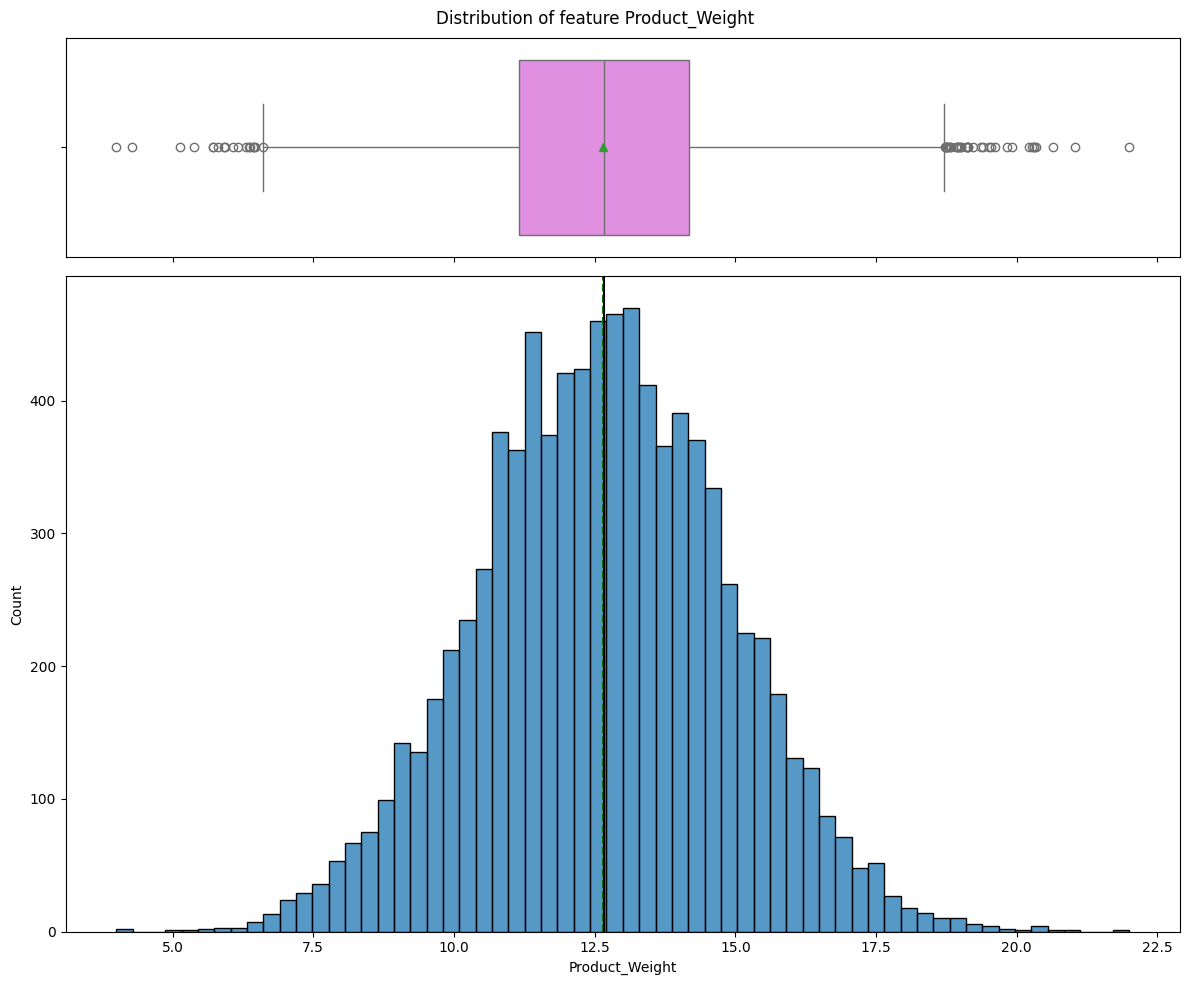

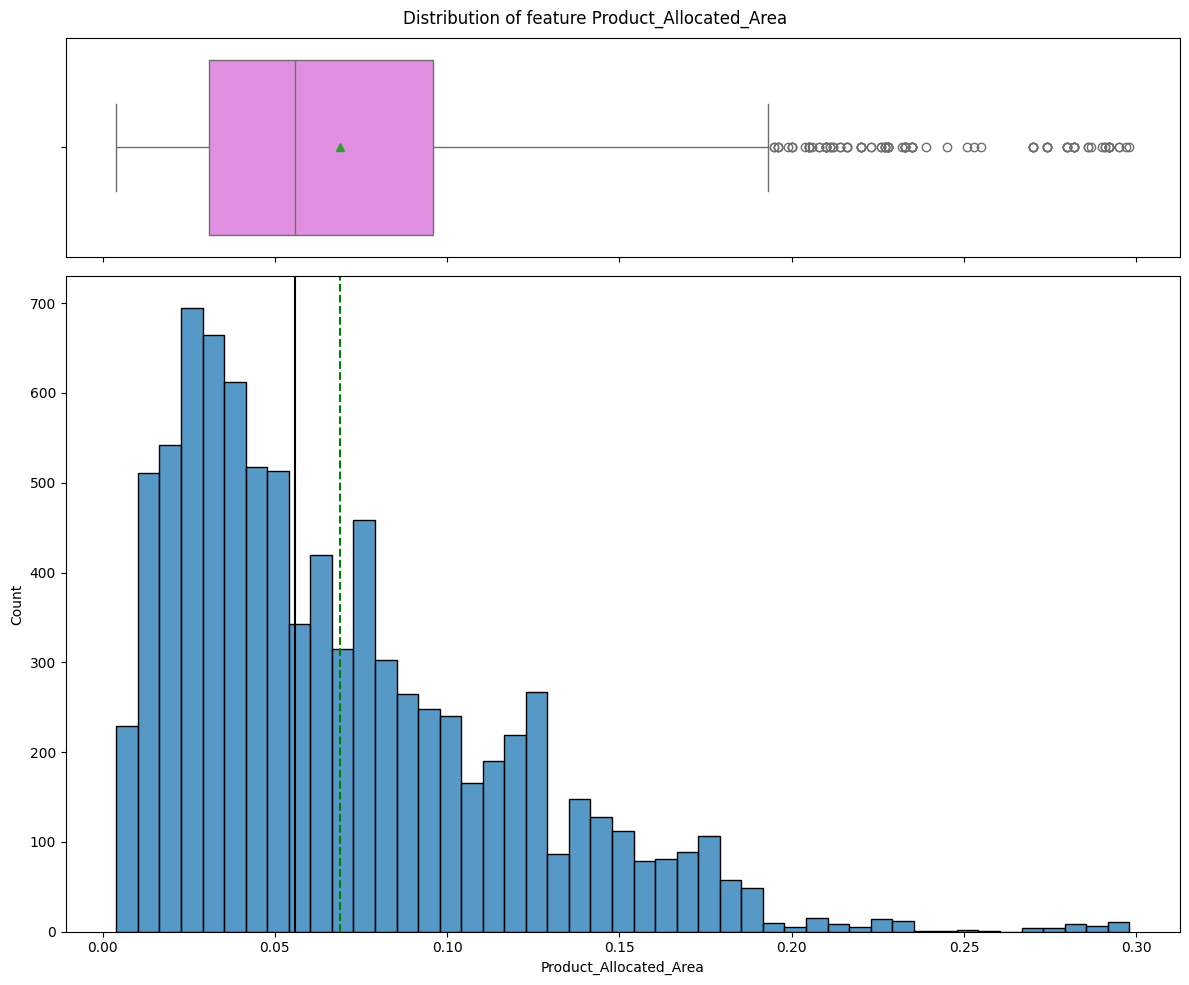

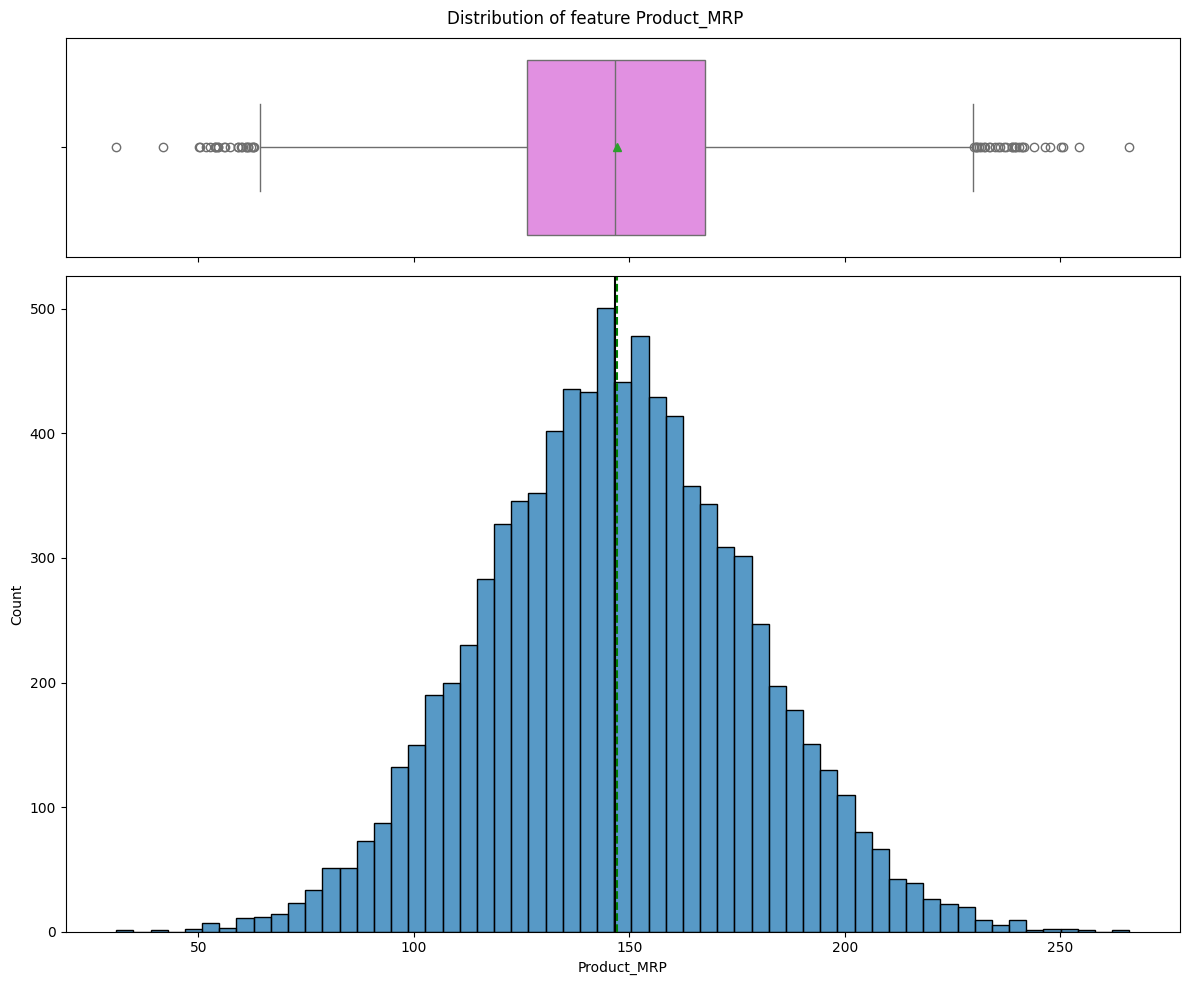

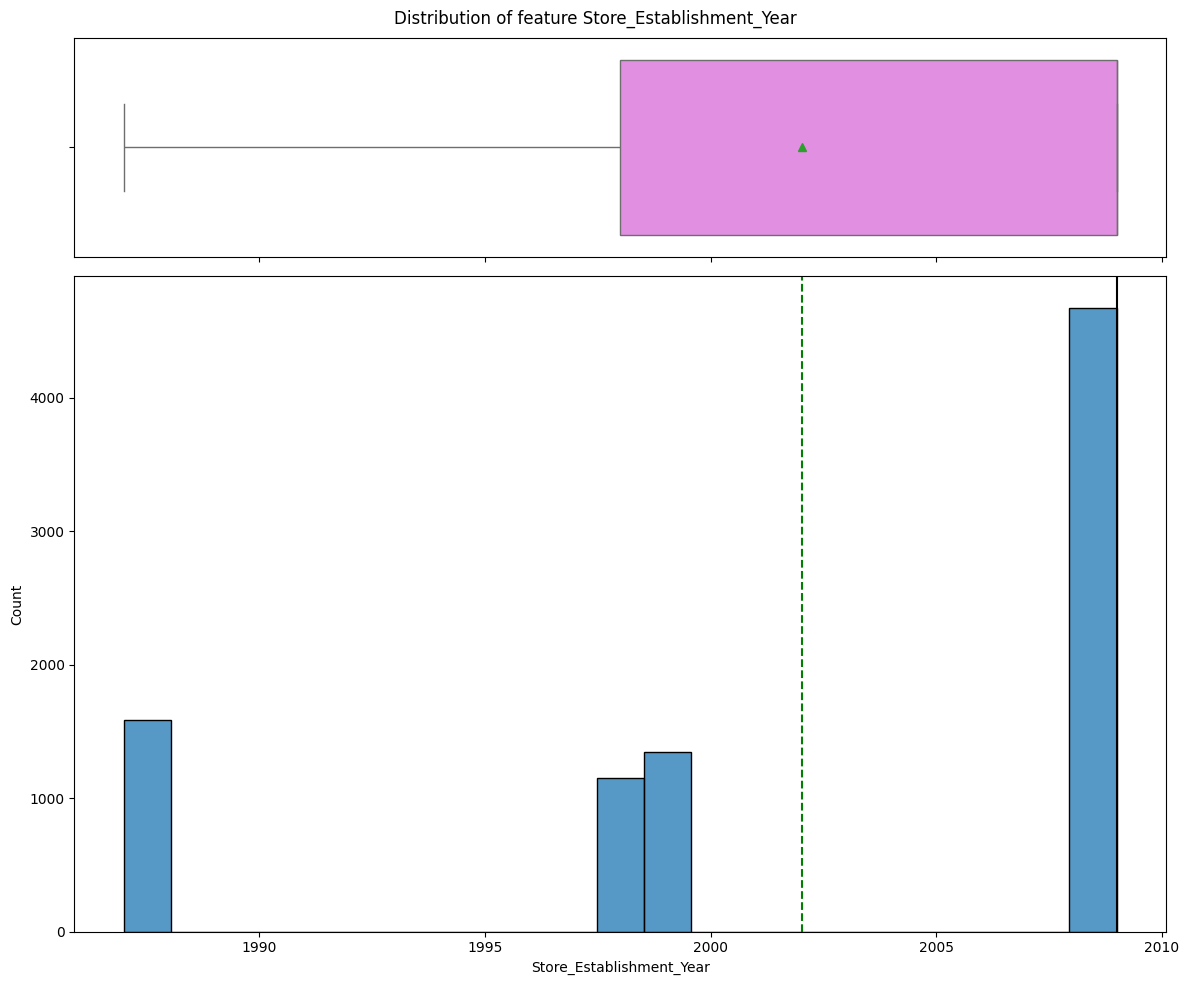

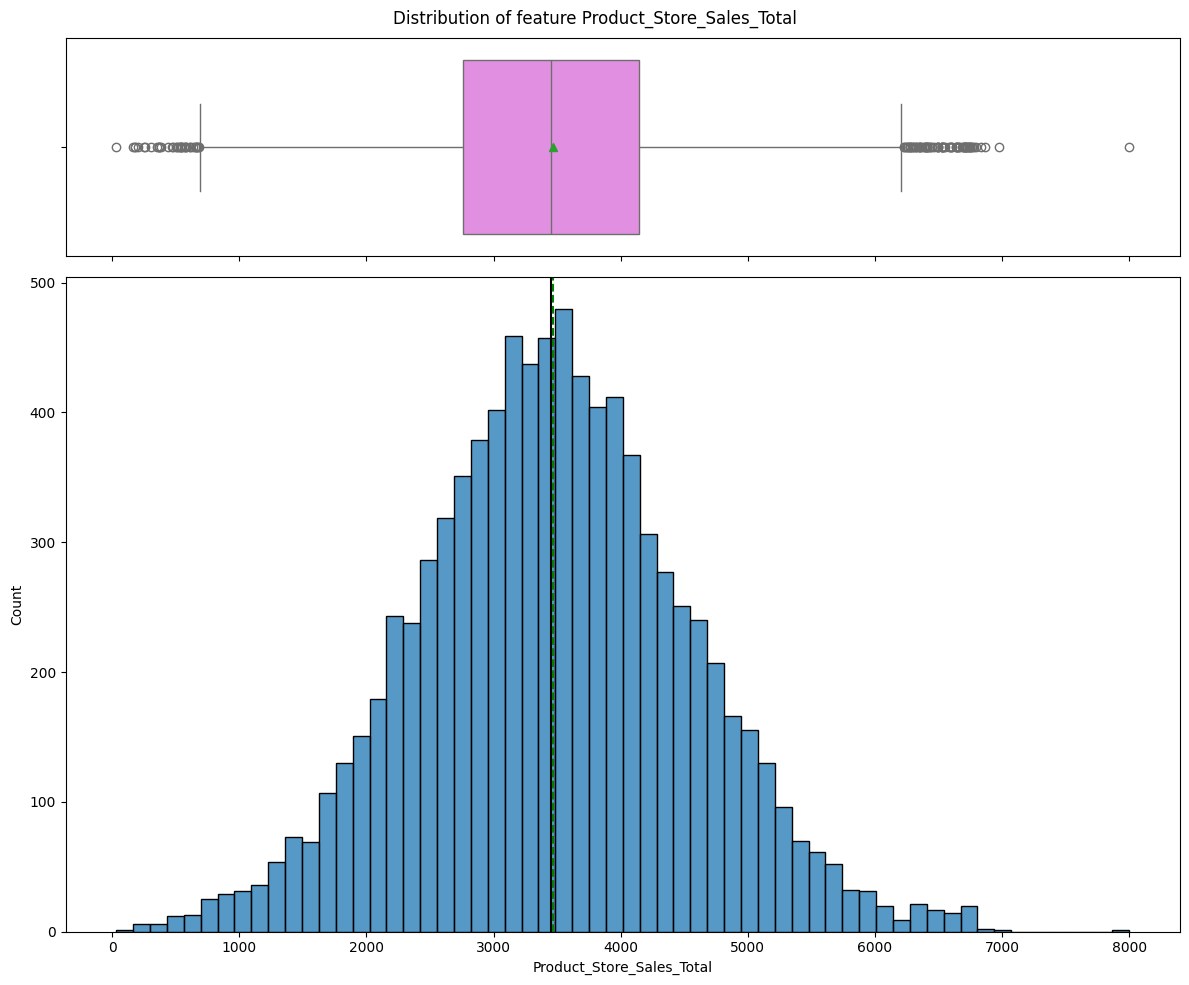

In [ ]:
# code for the loop to plot all the numeric columns
for cols in numeric_cols:
  histogram_boxplot(data, cols, figsize=(12,10), kde=False, bins=None, title=f"Distribution of feature {cols}")

**Observations:**


*  The distribution of **Product_Weight** appears relatively uniform, with no significant skewness or heavy tails.  
*   The distribution of **Product_Allocated_Area** is right-skewed, with most values concentrated near the lower end of the scale. The long tail and presence of outliers beyond the 75th percentile suggest that a small subset of products are allocated significantly larger shelf areas. This may be expected for high-demand or bulkier items, indicating a potential business-driven allocation strategy. These outliers are likely valid and informative rather than erroneous.
*   The **Product_MRP** distribution appears relatively uniform, with no significant skewness.
*   The distribution of **Store_Establishment_Year** is left-skewed, with most values concentrated toward more recent years (post-2009). The long tail on the left suggests a few older stores established prior to that time. Given that there are only four unique Store IDs in the dataset, the presence of clustered establishment years may point to one or more high-volume flagship stores, particularly those established around 2009.

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None,title=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot


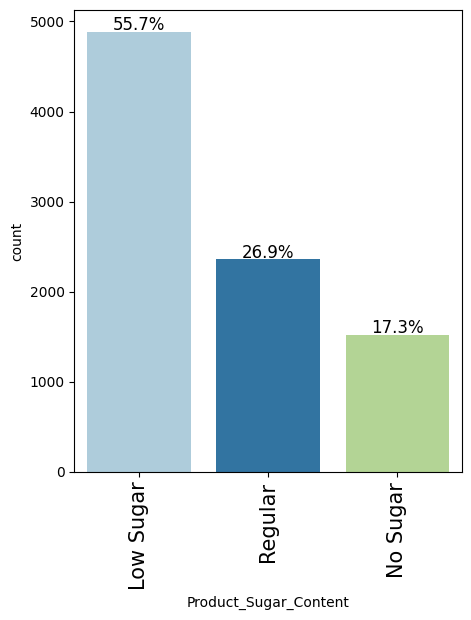

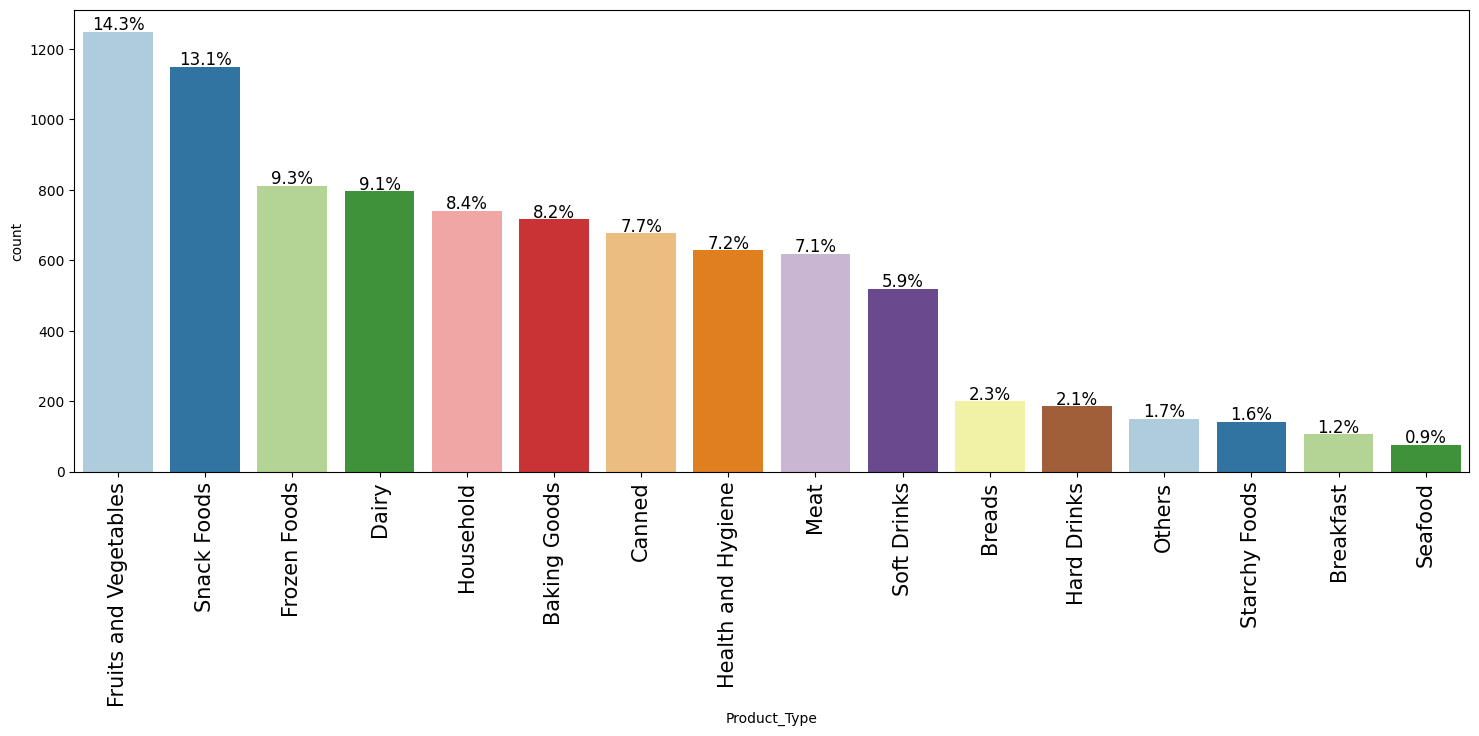

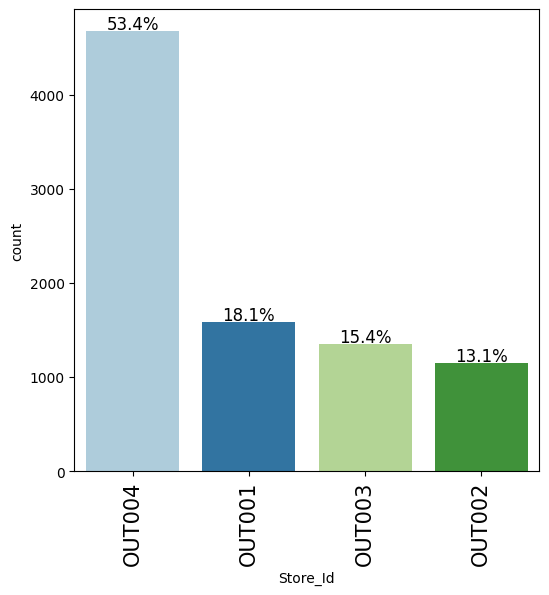

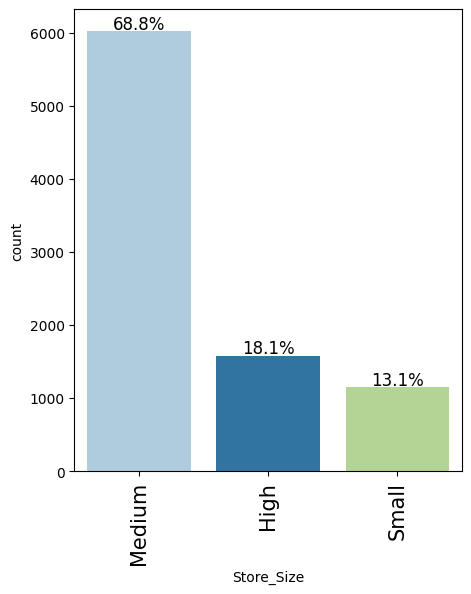

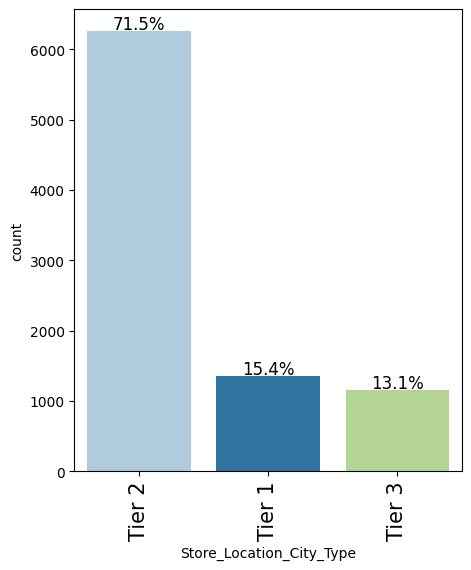

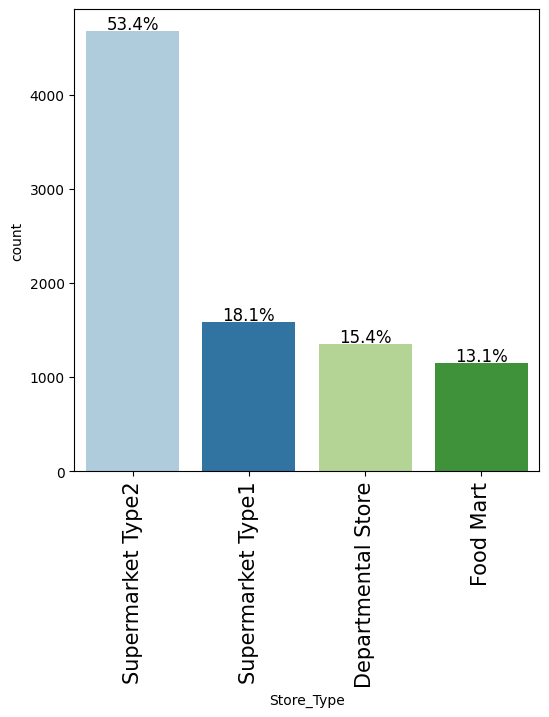

In [ ]:
# code for the loop to plot all the categorical columns
for cols in cat_cols:
  labeled_barplot(data, cols, perc=True,n=None, title=f"Distribution of feature {cols}")

**Observations:**


*   The majority of products fall under the 'Low Sugar' category, with 'Regular' and 'No Sugar' appearing much less frequently. The distribution appears clean and normalized.
*   Fruits and Vegetables, Snack Foods, and Frozen Foods have the highest counts, suggesting they are SuperKart's most common product categories.
*  Medium stores are by far the most common, with 6,025 entries. High stores are less frequent at 1,586 entries. Small stores are the least represented with 1,152 entries. This imbalance may reflect SuperKart's business model — possibly a greater reliance on medium-sized store formats. It's not a data issue, but it's worth considering for possible class imbalance for modeling.
*   The majority of stores are located in Tier 2 cities, with 6262 entries. This suggests SuperKart's operations are heavily concentrated in mid-sized urban centers (Tier 2).
*   The majority of stores are Supermarket Type2 (4676 records), which shows a class imbalance, which could influence model behavior if this variable has predictive power.

## Bivariate Analysis

In [ ]:
# dropping start and finish year from list of numerical columns as they are not numerical in nature
numeric_cols.remove("Store_Establishment_Year")

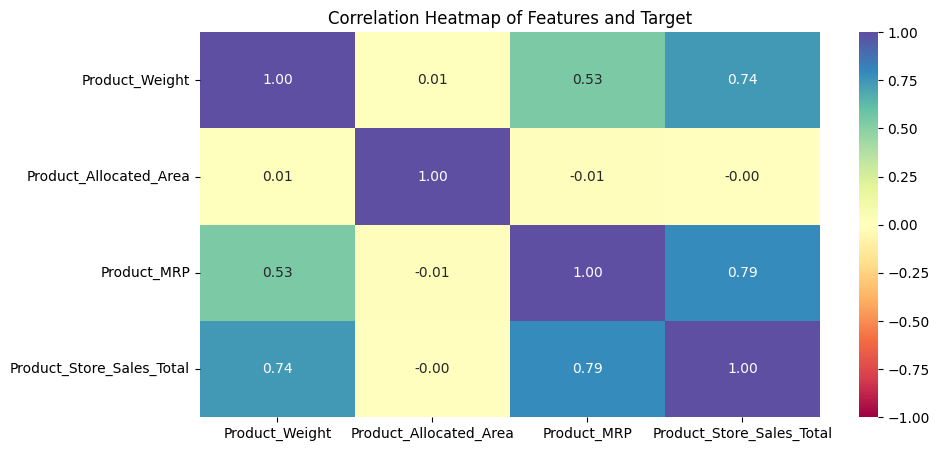

In [ ]:
# code for Correlation matrix
plt.figure(figsize=(10, 5))
sns.heatmap(
    data[numeric_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Observations:** The correlation matrix reveals two features with strong positive correlations to our target variable Product_Store_Sales_Total:


*   Product_MRP (correlation ≈ 0.79): This is expected — products with higher maximum retail prices will naturally generate higher total sales, assuming similar sales volumes.
*   Product_Weight (correlation ≈ 0.74): Heavier products may represent bulkier or premium items that command higher prices, which could explain their strong correlation with total sales.
*   Product_Allocated_Area has almost no correlation with total sales. This suggests that floor space allocation alone isn't a reliable predictor of sales performance.

**Check the distribution of our target variable i.e Product_Store_Sales_Total with the numeric columns**

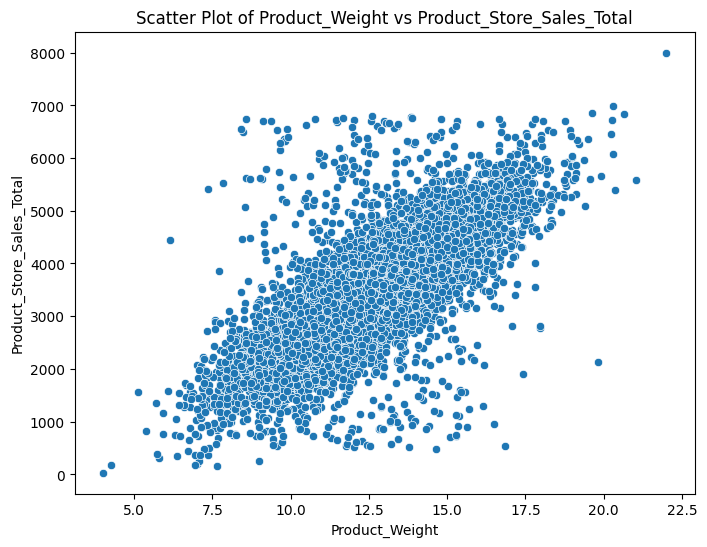

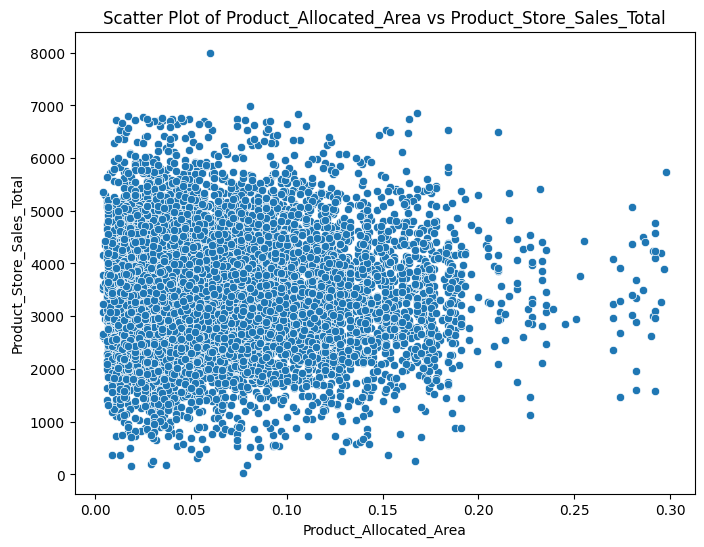

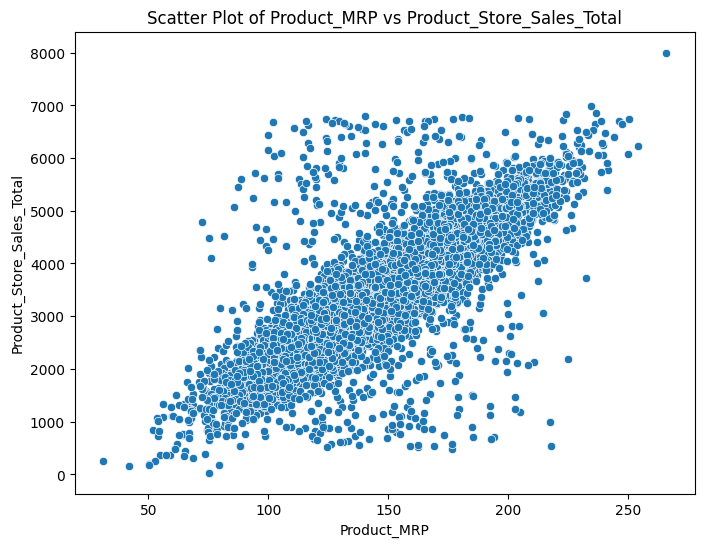

In [ ]:
target_variable = 'Product_Store_Sales_Total'
# Iterate over numeric columns, excluding the target variable itself
for col in [c for c in numeric_cols if c != target_variable]:
  plt.figure(figsize=[8, 6])
  # Access the column using bracket notation instead of dot notation
  sns.scatterplot(x=data[col], y=data[target_variable])
  plt.title(f'Scatter Plot of {col} vs {target_variable}') # Add a title for clarity
  plt.show()

**Observations:**
*  **Product_Weight** has a strong positive linear correlation with Product_Store_Sales_Total (r ≈ 0.74). This suggests that heavier products tend to generate higher sales — potentially due to their larger size, premium packaging, or greater volume, which could command higher retail prices.
*   There is a low correlation with **Product_Allocated_Area**. The Pearson coefficien is 0.00 but this may be due to skewed data with lots of outliers as we saw in the boxplot higher up in the notebook.
*   **Product_MRP** shows a strong positive correlation with Product_Store_Sales_Total (Pearson r ≈ 0.76). This is expected — as the unit price of a product increases, total revenue also increases assuming consistent or growing sales volume. he upward trend is quite clear, suggesting that pricing is a dominant driver of total sales. This makes Product_MRP a key feature in the model and a strong predictor of revenue.

**Location may have a high impact on the revenue of a store. Find out the type of stores and locations that are having a high impact on the revenue of the company.**

The type of store with the greatest revenue is Supermarket Type2
Overall sales for the best store type is 15427583.43
The location which generates the highest amount of revenue is Tier 2
Revenue for the top location type is 21650696.61


<Figure size 1200x600 with 0 Axes>

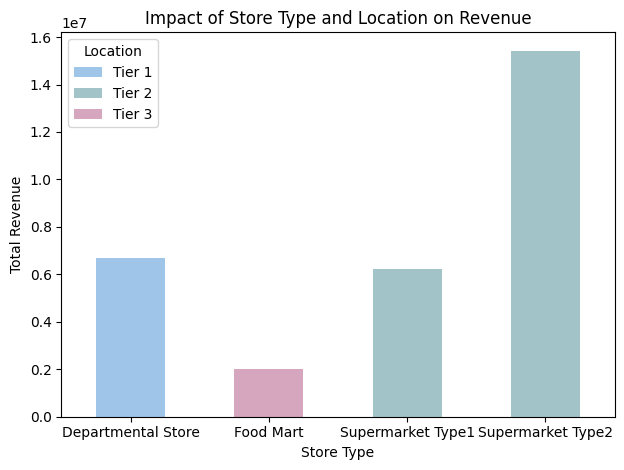

In [ ]:
# Group by 'Store_Type' and calculate the average revenue for each store type
store_type_revenue = data.groupby('Store_Type')['Product_Store_Sales_Total'].sum()

# Group by 'Store_Location_City_Type' and calculate the average revenue for each location
location_revenue = data.groupby('Store_Location_City_Type')['Product_Store_Sales_Total'].sum()

# Find the store type and location with the highest average revenue
top_store_type = store_type_revenue.idxmax()
top_store_type_revenue = store_type_revenue.max()

top_location = location_revenue.idxmax()
top_location_revenue = location_revenue.max()

print(f"The type of store with the greatest revenue is {top_store_type}")
print(f"Overall sales for the best store type is {top_store_type_revenue:.2f}")

print(f"The location which generates the highest amount of revenue is {top_location}")
print(f"Revenue for the top location type is {top_location_revenue:.2f}")

# Creating a pivot
store_location_revenue = data.pivot_table(index='Store_Type', columns='Store_Location_City_Type', values='Product_Store_Sales_Total', aggfunc='sum')

# Create a bar plot
plt.figure(figsize=(12, 6))
store_location_revenue.plot(kind='bar', stacked=True, color=['#9fc5e8', '#a2c4c9', '#d5a6bd'])
plt.xlabel('Store Type')
plt.ylabel('Total Revenue')
plt.title('Impact of Store Type and Location on Revenue')
plt.xticks(rotation=0)
plt.legend(title='Location')
plt.tight_layout()
plt.show()

**Observations:** Supermarket Type 2 is the store type with the highest revenue. The top store type has an overall sales of USD 15427583.43. Tier 2 is the location where the most revenue is made. The revenue for top location type is USD 21650696.61

**Different varieties of products are available at stores. A store needs to plan its inventory appropriately which is well aligned to the supply and demand characteristics. Which product type is contributing the most to the revenue of the SuperKart?**

The product type contributing the most to the revenue is: Fruits and Vegetables
Sales amount for the top product type: 4300833.27


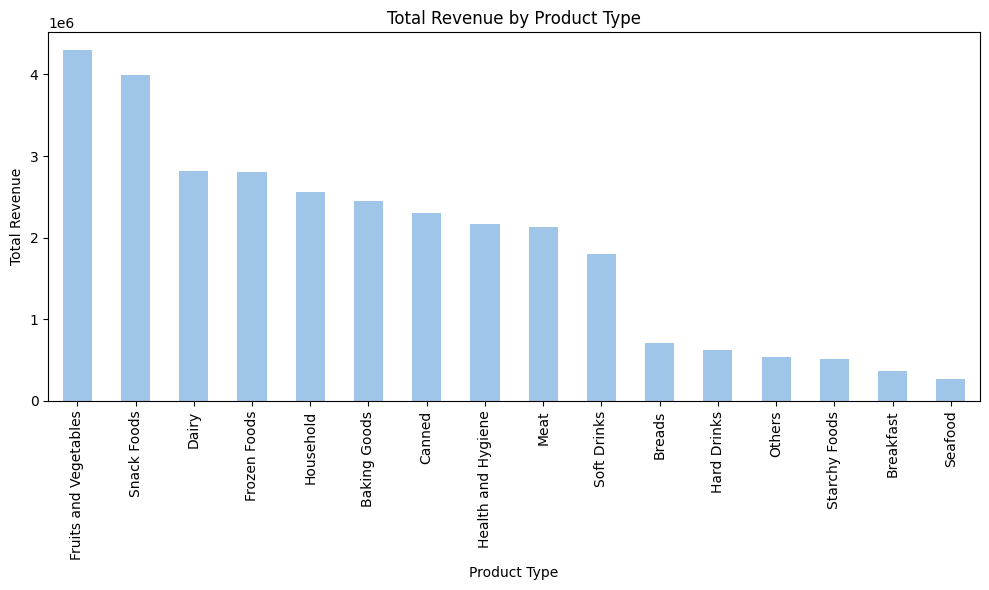

In [ ]:
# Group by 'Product_Type' and sum the 'Product_Store_Sales_Total' for each product type
revenue_by_product_type = data.groupby('Product_Type')['Product_Store_Sales_Total'].sum()

# Sort the result in descending order to find the product type with the highest revenue
sorted_revenue = revenue_by_product_type.sort_values(ascending=False)

# Find the product type with the highest revenue
top_product_type = revenue_by_product_type.idxmax()
top_product_sales_amount = revenue_by_product_type.max()

print(f"The product type contributing the most to the revenue is: {top_product_type}")
print(f"Sales amount for the top product type: {top_product_sales_amount:.2f}")


# Create a bar plot
plt.figure(figsize=(10, 6))
sorted_revenue.plot(kind='bar', color=['#9fc5e8'])
plt.xlabel('Product Type')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Product Type')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Observations:** The product type contributing the most to the revenue is: Fruits and Vegetables with sales amount of $4300833.27

**Many customers prefer products that have low sugar content in them. How many items have been sold in each of the 16 product types that have low sugar content in them?**

Product_Type
Fruits and Vegetables    864
Snack Foods              804
Dairy                    590
Frozen Foods             531
Baking Goods             462
Canned                   402
Meat                     377
Soft Drinks              370
Breads                   148
Hard Drinks              128
Starchy Foods             97
Breakfast                 65
Seafood                   47
Name: Product_Store_Sales_Total, dtype: int64


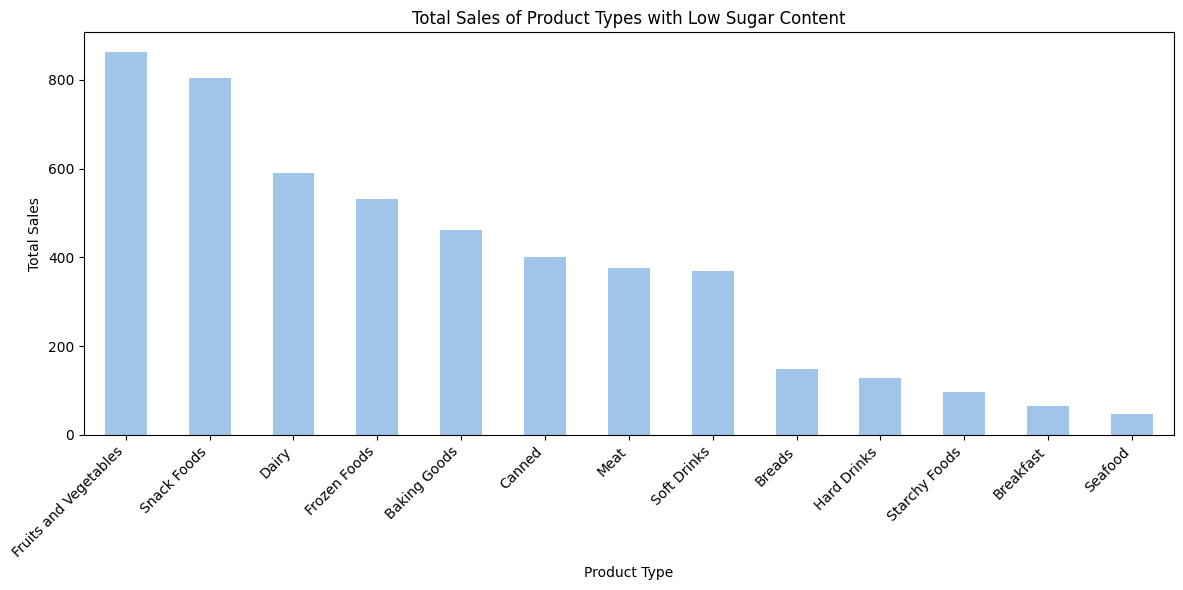

In [ ]:
# Filter the DataFrame to rows with 'Product_Sugar_Content' set to 'Low'.
low_sugar_data = data[data['Product_Sugar_Content'] == 'Low Sugar']

# Count the quantity of each product type sold after grouping by 'Product_Type'
items_sold_by_product_type = low_sugar_data.groupby('Product_Type')['Product_Store_Sales_Total'].count().sort_values(ascending=False)

print(items_sold_by_product_type)

# Create a bar plot
plt.figure(figsize=(12, 6))
items_sold_by_product_type.plot(kind='bar', color=['#9fc5e8'])
plt.xlabel('Product Type')
plt.ylabel('Total Sales')
plt.title('Total Sales of Product Types with Low Sugar Content')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observations:**
*   The category "Fruits and Vegetables" saw sales of 864 items.
*   804 items were sold under the "Snack Foods" category.
*   590 products under the "Dairy" category were sold.
*   The "Frozen Foods" category had sales of 531 different items overall.
*   62 products in the "Baking Goods" category were sold.
*   There were 377 sales of "Meat" products.
*   There were 370 goods sold under the "Soft Drinks" category.
*   148 products in the "Breads" category were sold.
*   128 items fell under the "Hard Drinks" category and were sold.
*   There were 97 products marketed under the "Starchy Foods" category.
*   There were 65 sales in the "Breakfast" category.
*   Finally, 47 goods were sold under the "Seafood" category.

**Which product type the company is generating most of the revenue?**

Product type sold the most number of times in each store:
Store_Id
OUT001              (OUT001, Snack Foods)
OUT002    (OUT002, Fruits and Vegetables)
OUT003              (OUT003, Snack Foods)
OUT004    (OUT004, Fruits and Vegetables)
Name: Product_Store_Sales_Total, dtype: object

Product type contributing the most to the revenue of each store:
Store_Id
OUT001              (OUT001, Snack Foods)
OUT002    (OUT002, Fruits and Vegetables)
OUT003              (OUT003, Snack Foods)
OUT004    (OUT004, Fruits and Vegetables)
Name: Product_Store_Sales_Total, dtype: object


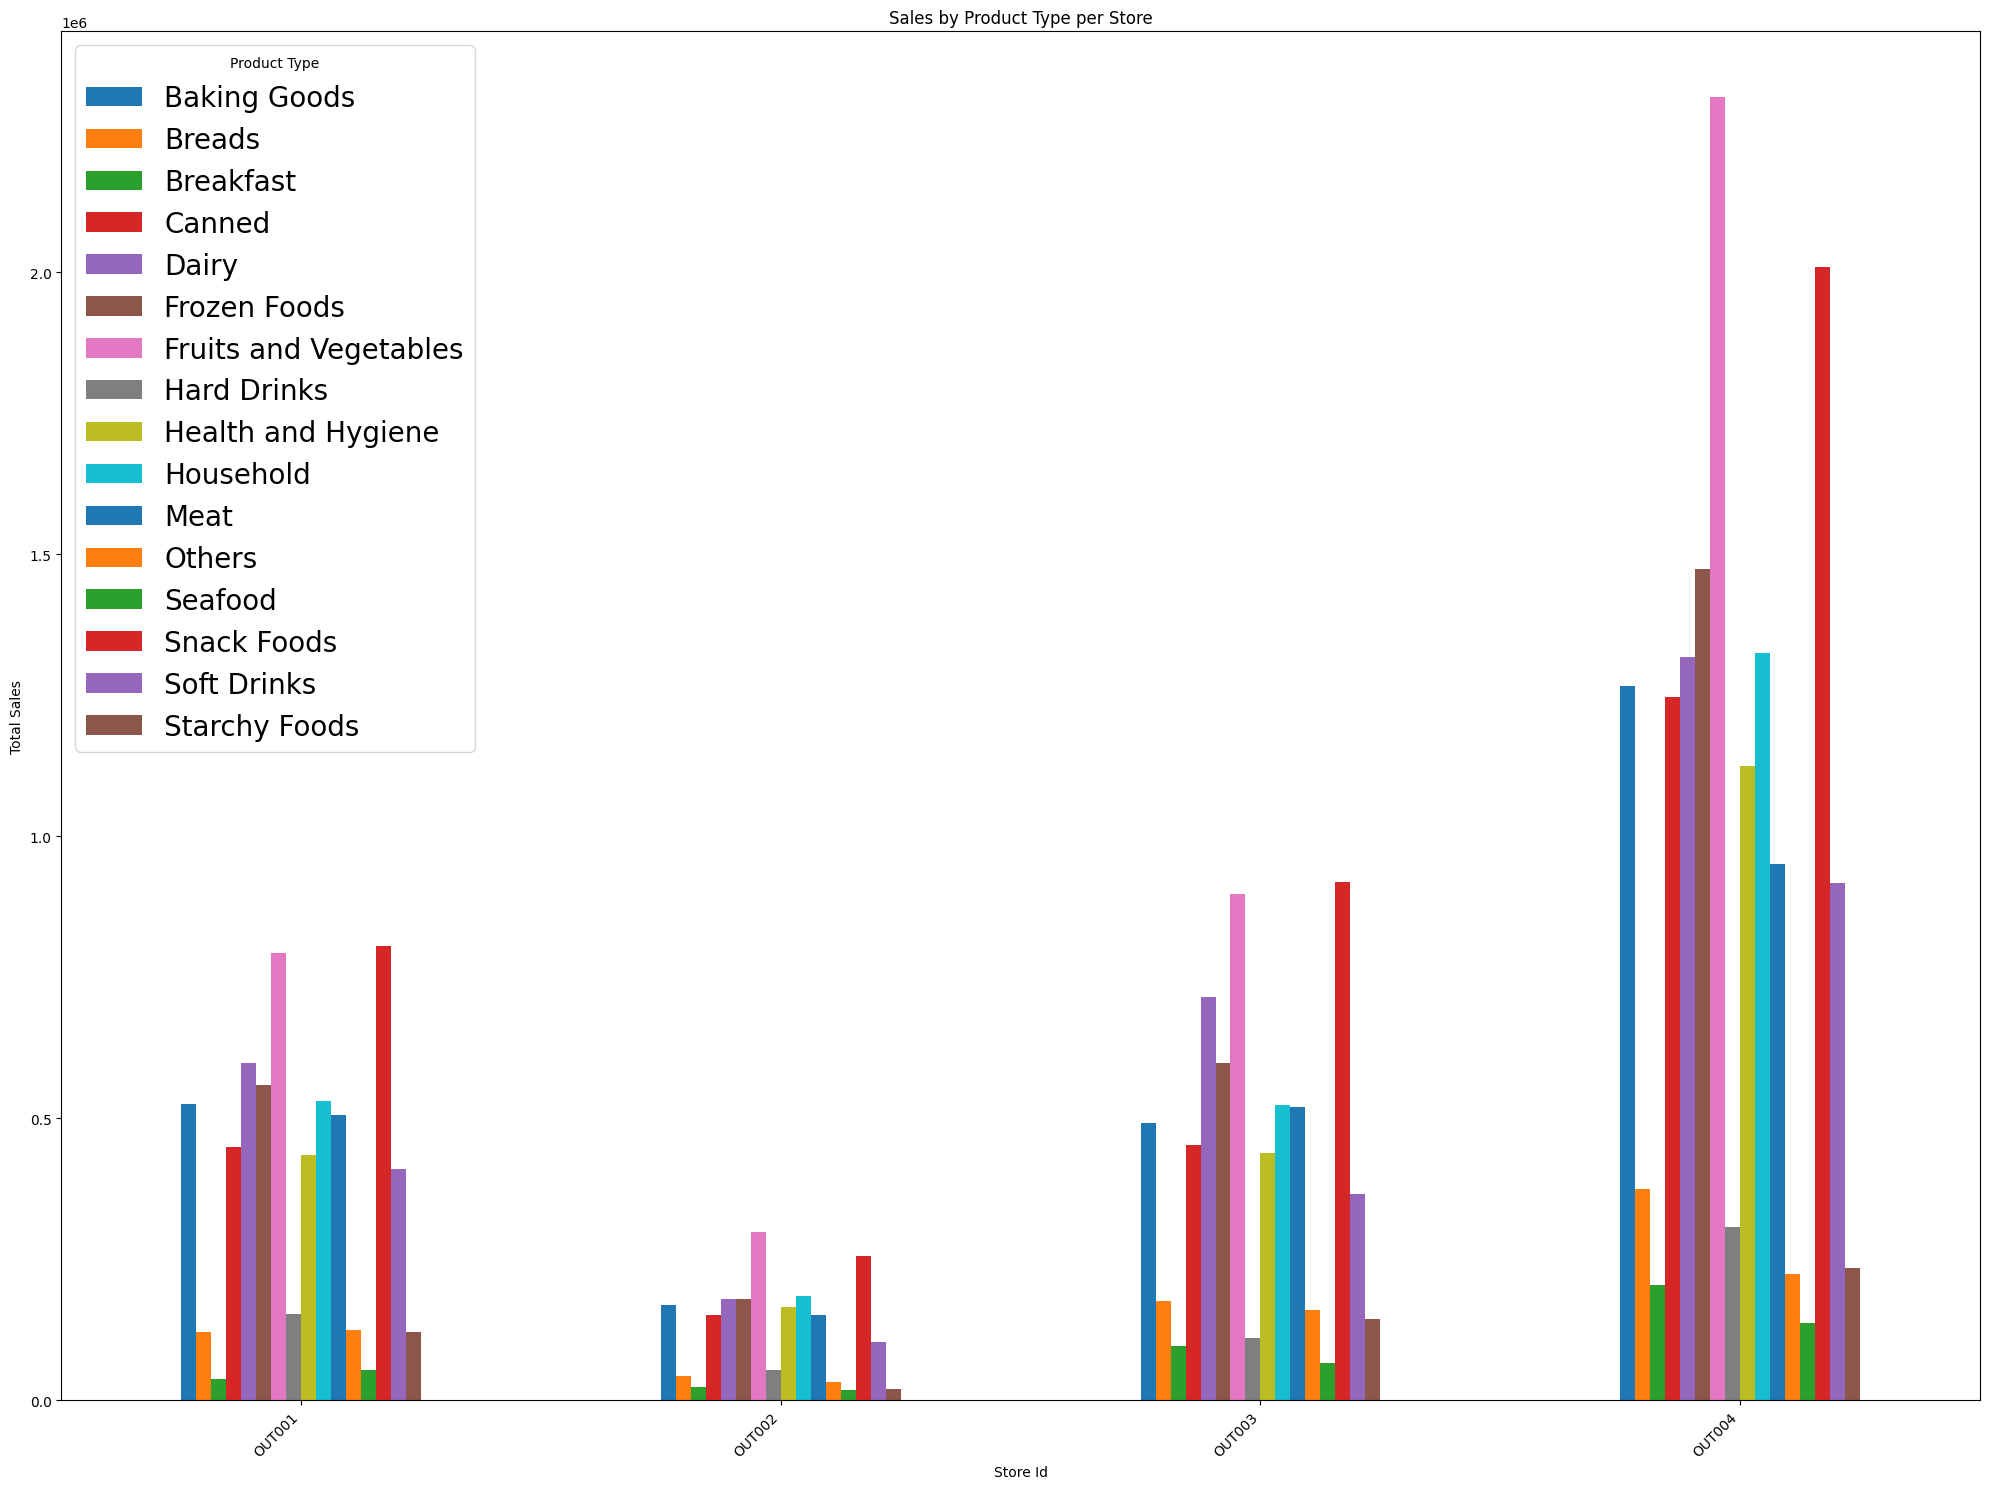

In [ ]:
product_count_by_store = df.groupby(['Store_Id', 'Product_Type'])['Product_Store_Sales_Total'].count()

max_sold_product_by_store = product_count_by_store.groupby(level='Store_Id').idxmax()

print("Product type sold the most number of times in each store:")
print(max_sold_product_by_store)

revenue_by_product_type = df.groupby(['Store_Id', 'Product_Type'])['Product_Store_Sales_Total'].sum()

top_revenue_product_by_store = revenue_by_product_type.groupby(level='Store_Id').idxmax()

print("\nProduct type contributing the most to the revenue of each store:")
print(top_revenue_product_by_store)

sales_by_product_type_per_store = df.groupby(['Store_Id', 'Product_Type'])['Product_Store_Sales_Total'].sum().unstack()

fig, ax = plt.subplots(figsize=(20, 15))

sales_by_product_type_per_store.plot(kind='bar', ax=ax)
ax.set_xlabel('Store Id')
ax.set_ylabel('Total Sales')
ax.set_title('Sales by Product Type per Store')
ax.set_xticklabels(sales_by_product_type_per_store.index, rotation=45, ha='right')

legend = ax.legend(title='Product Type', prop={'size': 20})

plt.tight_layout()
plt.show()

**Observations:**  

*   Snack Foods are the product type sold most frequently at the OUT001 store.
*   Fruits and vegetables are the product category that OUT002 and OUT004 stores sell the most.
*   Snack Foods are the product category that OUT003 store sells the most.

**Which store has sold more costly goods than others?**

Store with highest average MRP: OUT003


Text(0.5, 1.0, 'Store with highest average MRP')

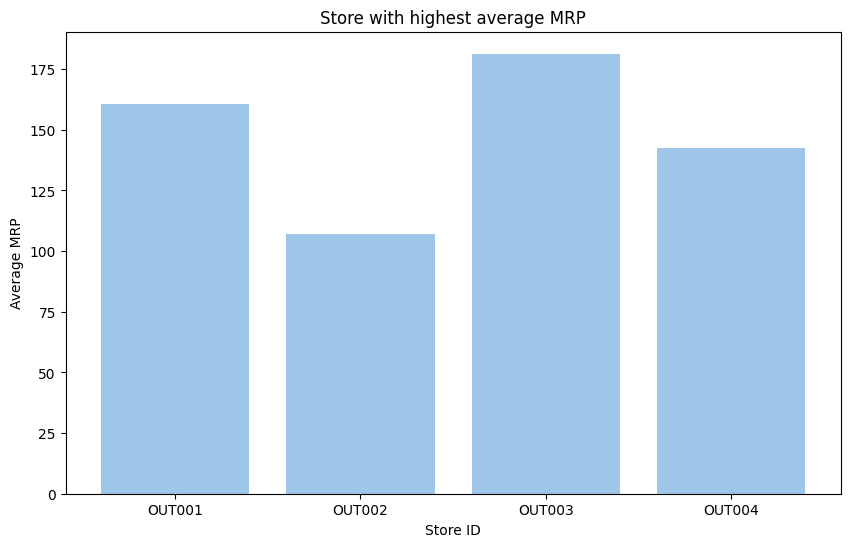

In [ ]:
# Group by Store_Id and calculating the average MRP for each store
store_average_mrp = data.groupby('Store_Id')['Product_MRP'].mean()

# Finding the store with the highest average MRP
highest_avg_mrp_store = store_average_mrp.idxmax()

print("Store with highest average MRP:", highest_avg_mrp_store)

# Highlight the store with the highest average MRP
plt.figure(figsize=(10, 6))
plt.bar(store_average_mrp.index, store_average_mrp.values, color='#9fc5e8')
plt.xlabel('Store ID')
plt.ylabel('Average MRP')
plt.title('Store with highest average MRP')

**Observations:** On an average, store id OUT003 sells higher priced items then others.

**Different product types have different prices. Let's analyze the trend**

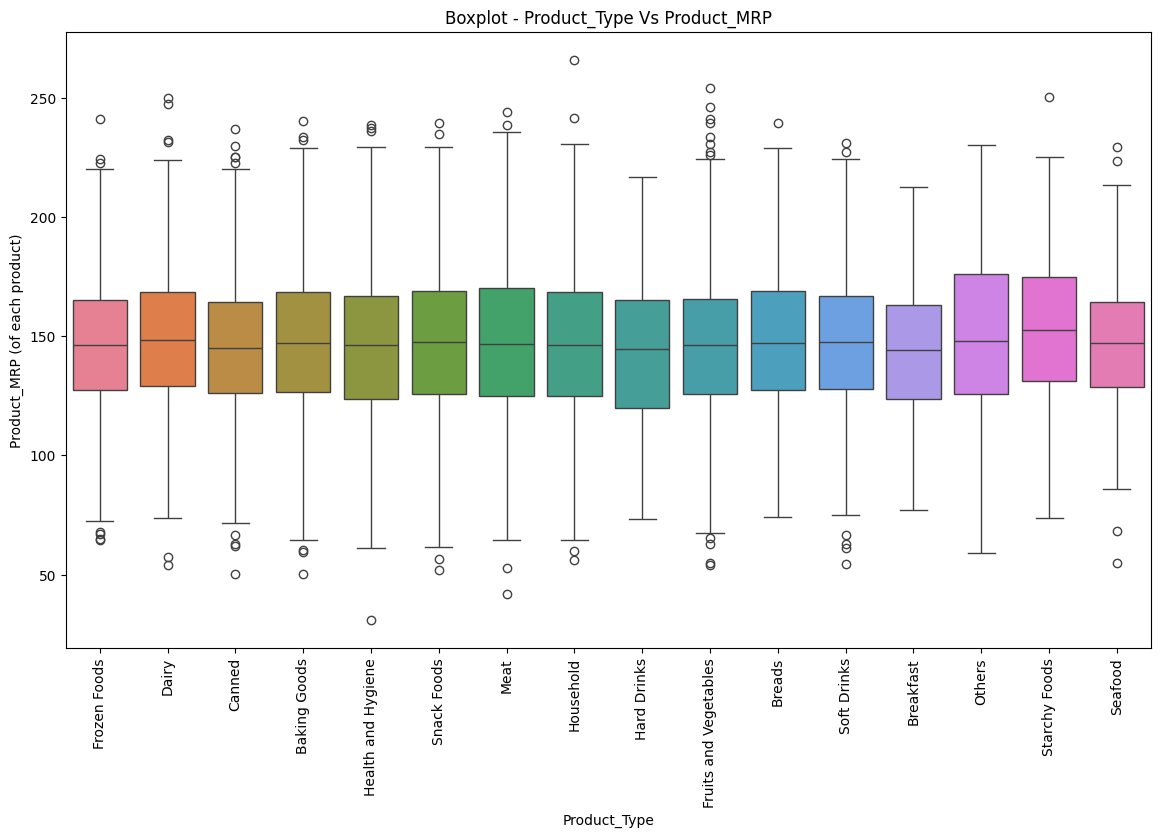

In [ ]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_MRP", hue = "Product_Type")
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_MRP")
plt.xlabel("Product_Type")
plt.ylabel("Product_MRP (of each product)")
plt.show()

**Observations:** Most products are fairly evenly distributed and contribute fairly equally to overall total store sales, although Stachy Foods is slightly higher than the rest.
Product_Type alone, may not be a strong feature in our model.

**Details of each store sorted by average total sales by store**

In [ ]:
# Group, aggregate, and sort by total revenue
store_avg_info = (
    data.groupby('Store_Id')[['Store_Size', 'Store_Type', 'Product_Store_Sales_Total']]
    .agg({
        'Store_Size': 'first',
        'Store_Type': 'first',
        'Product_Store_Sales_Total': 'mean'
    })
    .reset_index()
    .sort_values(by='Product_Store_Sales_Total', ascending=False)
)

# Display the DataFrame in a clean tabular format
# Format large numbers with commas
store_avg_info['Product_Store_Sales_Total'] = store_avg_info['Product_Store_Sales_Total'].apply(lambda x: f"{x:,.0f}")

# Show the DataFrame
from IPython.display import display
display(store_avg_info)

,Store_Id,Store_Size,Store_Type,Product_Store_Sales_Total
2,OUT003,Medium,Departmental Store,"4,947"
0,OUT001,High,Supermarket Type1,"3,924"
3,OUT004,Medium,Supermarket Type2,"3,299"
1,OUT002,Small,Food Mart,"1,763"


**Observations:** Store ID OUT003 has the highest average sales by store.

**Total sales revenue by Product Type per Store**

In [ ]:
# Generate table displaying total sales revenue by Product Type per Store
pivot_sales_revenue = data.pivot_table(
    index='Product_Type',
    columns='Store_Id',
    values='Product_Store_Sales_Total',
    aggfunc='sum',
    fill_value=0
)

pivot_sales_revenue = pivot_sales_revenue.sort_values(by=pivot_sales_revenue.columns.tolist(), ascending=False)
display(pivot_sales_revenue)

Store_Id,OUT001,OUT002,OUT003,OUT004
Product_Type,,,,
Snack Foods,806142.24,255317.57,918510.44,2009026.70
Fruits and Vegetables,792992.59,298503.56,897437.46,2311899.66
Dairy,598767.62,178888.18,715814.94,1318447.30
Frozen Foods,558556.81,180295.95,597608.42,1473519.65
Household,531371.38,184665.65,523981.64,1324721.50
Baking Goods,525131.04,169860.50,491908.20,1266086.26
Meat,505867.28,151800.01,520939.68,950604.97
Canned,449016.38,151467.66,452445.17,1247153.50
Health and Hygiene,435005.31,164660.81,439139.18,1124901.91


**Observations:** There is no anomalous items in the date above.

**Let's delve deeper and do a detailed analysis of each of the stores**

**Store 1. OUT001**

In [ ]:
# Overall summary table for store 1
data.loc[data["Store_Id"] == "OUT001"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Weight,1586.0,NaN,NaN,NaN,13.458865,2.064975,6.16,12.0525,13.96,14.95,17.97
Product_Sugar_Content,1586,3,Low Sugar,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1586.0,NaN,NaN,NaN,0.068768,0.047131,0.004,0.033,0.0565,0.094,0.295
Product_Type,1586,16,Snack Foods,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1586.0,NaN,NaN,NaN,160.514054,30.359059,71.35,141.72,168.32,182.9375,226.59
Store_Id,1586,1,OUT001,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1586.0,NaN,NaN,NaN,1987.0,0.0,1987.0,1987.0,1987.0,1987.0,1987.0
Store_Size,1586,1,High,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1586,1,Tier 2,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Type,1586,1,Supermarket Type1,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations:**
Store OUT001 is a Supermarket Type1 store.
It's in a Tier 2 city location.
It was established in 1987.
It's a store size of type High.
It earns most of it's revenue from snack foods, followed by Fruits and Vegetables
It earns the least on Breakfast Foods.

In [ ]:
# Total sales per store type
data.loc[data["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()

np.float64(6223113.18)

**Observations:** OUT001 has generated total revenue of 6223113 from the sales of goods

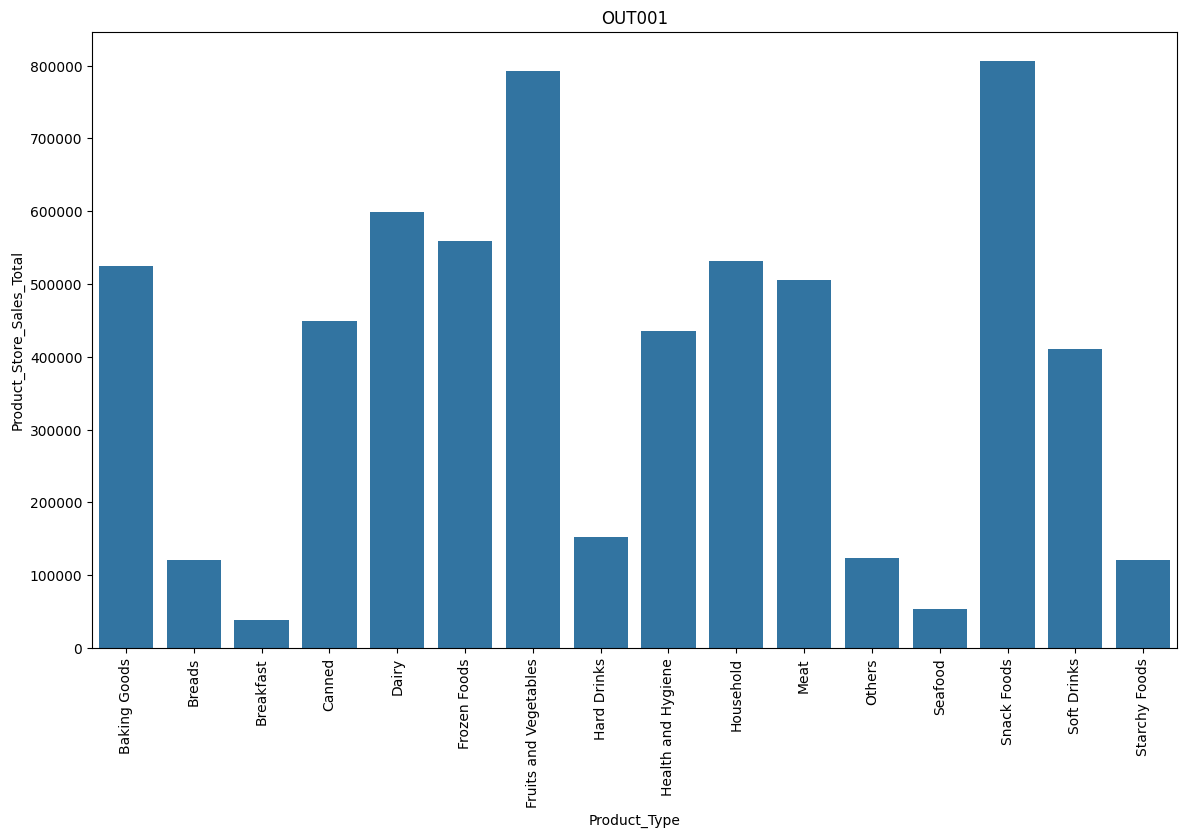

In [ ]:
# Barplot of sales per product type
data_OUT001 = (
    data.loc[data["Store_Id"] == "OUT001"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT001")
sns.barplot(x=data_OUT001.Product_Type, y=data_OUT001.Product_Store_Sales_Total)
plt.show()

**Observations:** OUT001 has generated the highest revenue from the sale of fruits and vegetables and snack foods. Both the categories have contributed around 800000 each.

**Store 2. OUT002**

In [ ]:
# Overall summary table for store 2
data.loc[data["Store_Id"] == "OUT002"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Weight,1152.0,NaN,NaN,NaN,9.911241,1.799846,4.0,8.7675,9.795,10.89,19.82
Product_Sugar_Content,1152,3,Low Sugar,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1152.0,NaN,NaN,NaN,0.067747,0.047567,0.006,0.031,0.0545,0.09525,0.292
Product_Type,1152,16,Fruits and Vegetables,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1152.0,NaN,NaN,NaN,107.080634,24.912333,31.0,92.8275,104.675,117.8175,224.93
Store_Id,1152,1,OUT002,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1152.0,NaN,NaN,NaN,1998.0,0.0,1998.0,1998.0,1998.0,1998.0,1998.0
Store_Size,1152,1,Small,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1152,1,Tier 3,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Type,1152,1,Food Mart,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations:** We can see from the data above, Store OUT002 is a Food Mart.
It's in a Tier 3 city location.
It was established in 1998.
It's a store size of type Small.
It earns most of it's revenue from Fruits and Vegetables followed by Snack Foods
It earns the least on Seafood.

In [ ]:
# Total sales per store type
data.loc[data["Store_Id"] == "OUT002", "Product_Store_Sales_Total"].sum()

**Observations:** OUT002 has generated total revenue of 2030910 from the sales of goods.

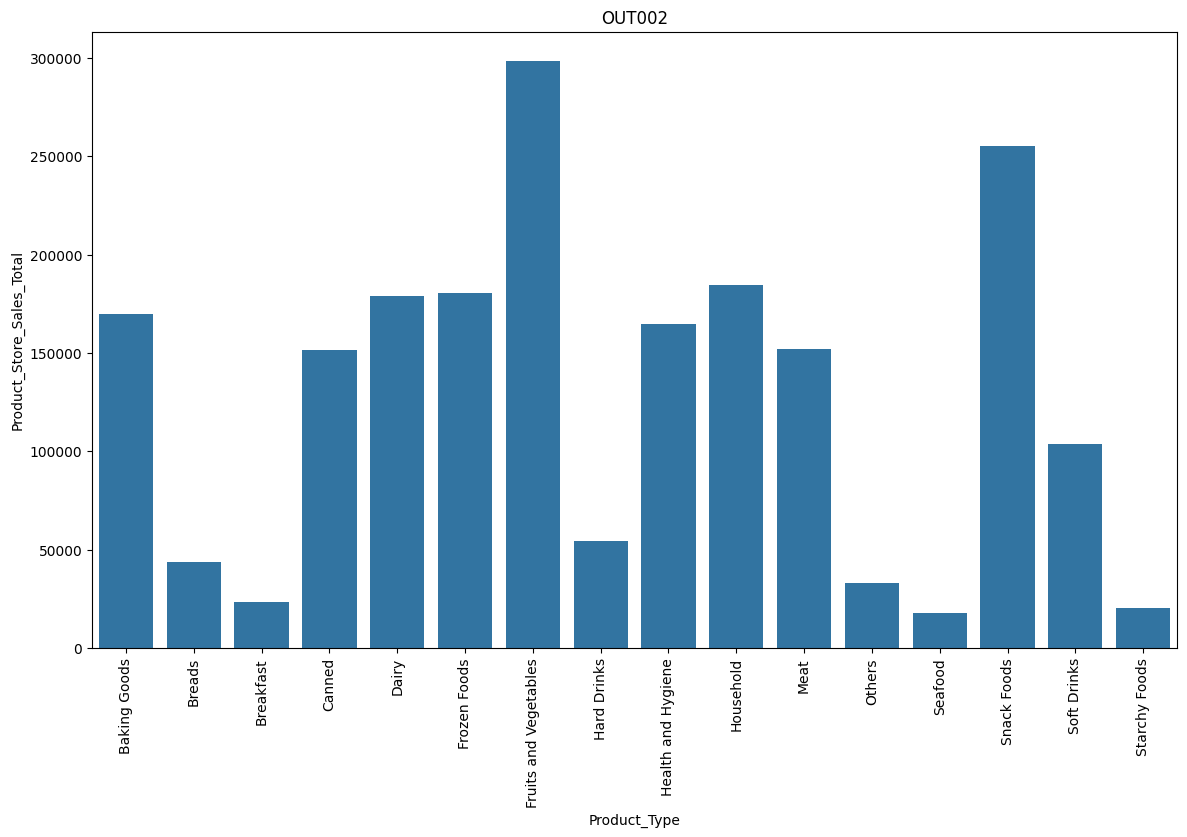

In [ ]:
# Barplot of sales per product type
data_OUT002 = (
    data.loc[data["Store_Id"] == "OUT002"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT002")
sns.barplot(x=data_OUT002.Product_Type, y=data_OUT002.Product_Store_Sales_Total)
plt.show()

**Observations:** OUT002 has generated the highest revenue from the sale of fruits and vegetables (~ 300000) followed by snack foods (~ 250000).

**Store 3. OUT003**

In [ ]:
# Overall summary table for store 3
data.loc[data["Store_Id"] == "OUT003"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Weight,1349.0,NaN,NaN,NaN,15.103692,1.893531,7.35,14.02,15.18,16.35,22.0
Product_Sugar_Content,1349,3,Low Sugar,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1349.0,NaN,NaN,NaN,0.068637,0.048708,0.004,0.031,0.057,0.094,0.298
Product_Type,1349,16,Snack Foods,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1349.0,NaN,NaN,NaN,181.358725,24.796429,85.88,166.92,179.67,198.07,266.0
Store_Id,1349,1,OUT003,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1349.0,NaN,NaN,NaN,1999.0,0.0,1999.0,1999.0,1999.0,1999.0,1999.0
Store_Size,1349,1,Medium,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1349,1,Tier 1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Type,1349,1,Departmental Store,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations:** Store OUT003 is a Department Store.
It's in a Tier 1 city location.
It was established in 1999.
It's a store size of type Medium.
It earns most of it's revenue from Snack Foods followed by Fruits and Vegetables similar to Store OUT001
It also earns the least on Seafood.

In [ ]:
# Total sales per store type
data.loc[data["Store_Id"] == "OUT003", "Product_Store_Sales_Total"].sum()

np.float64(6673457.57)

**Observations:** OUT003 has generated total revenue of 6673458 from the sales of goods.

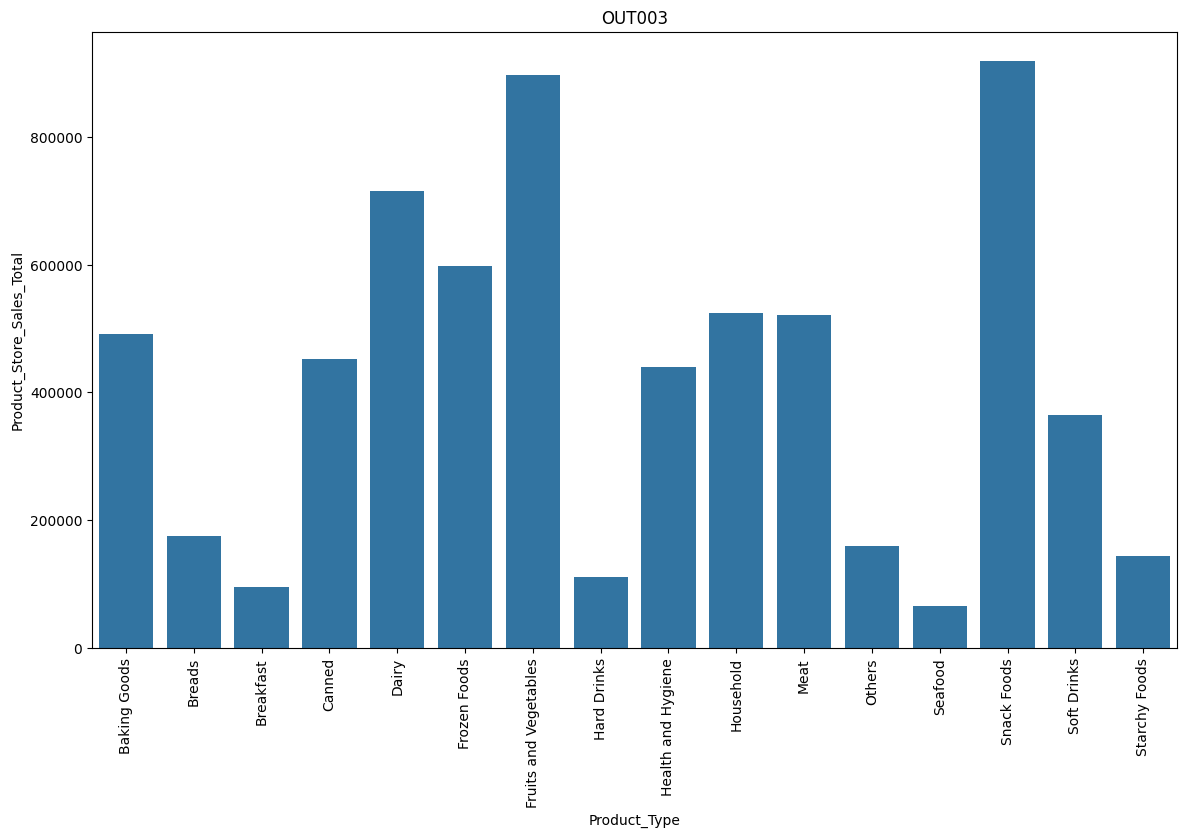

In [ ]:
# Barplot of sales per product type
data_OUT003 = (
    data.loc[data["Store_Id"] == "OUT003"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT003")
sns.barplot(x=data_OUT003.Product_Type, y=data_OUT003.Product_Store_Sales_Total)
plt.show()

**Observations:** OUT003 has generated the highest revenue from the sale of snack foods followed by fruits and vegetables, both the categories contributing around 800000 each.

**Store 4. OUT004**

In [ ]:
# Overall summary table for store 4
data.loc[data["Store_Id"] == "OUT004"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Weight,4676.0,NaN,NaN,NaN,12.349613,1.428199,7.34,11.37,12.37,13.3025,17.79
Product_Sugar_Content,4676,3,Low Sugar,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,4676.0,NaN,NaN,NaN,0.069092,0.048584,0.004,0.031,0.056,0.097,0.297
Product_Type,4676,16,Fruits and Vegetables,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,4676.0,NaN,NaN,NaN,142.399709,17.513973,83.04,130.54,142.82,154.1925,197.66
Store_Id,4676,1,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,4676.0,NaN,NaN,NaN,2009.0,0.0,2009.0,2009.0,2009.0,2009.0,2009.0
Store_Size,4676,1,Medium,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,4676,1,Tier 2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Type,4676,1,Supermarket Type2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations:** Store OUT004 is a Supermarket Type2 Store.
It's in a Tier 2 city location.
It was established in 2009.
It's a store size of type Medium.
It earns most of it's revenue from Fruits and Vegetables followed by Snack Foods similar to Store OUT002
It also earns the least on Seafood.

In [ ]:
# Total sales per store type
data.loc[data["Store_Id"] == "OUT004", "Product_Store_Sales_Total"].sum()

**Observations:** OUT004 has generated total revenue of 15427583 from the sales of goods which is highest among all the 4 stores.

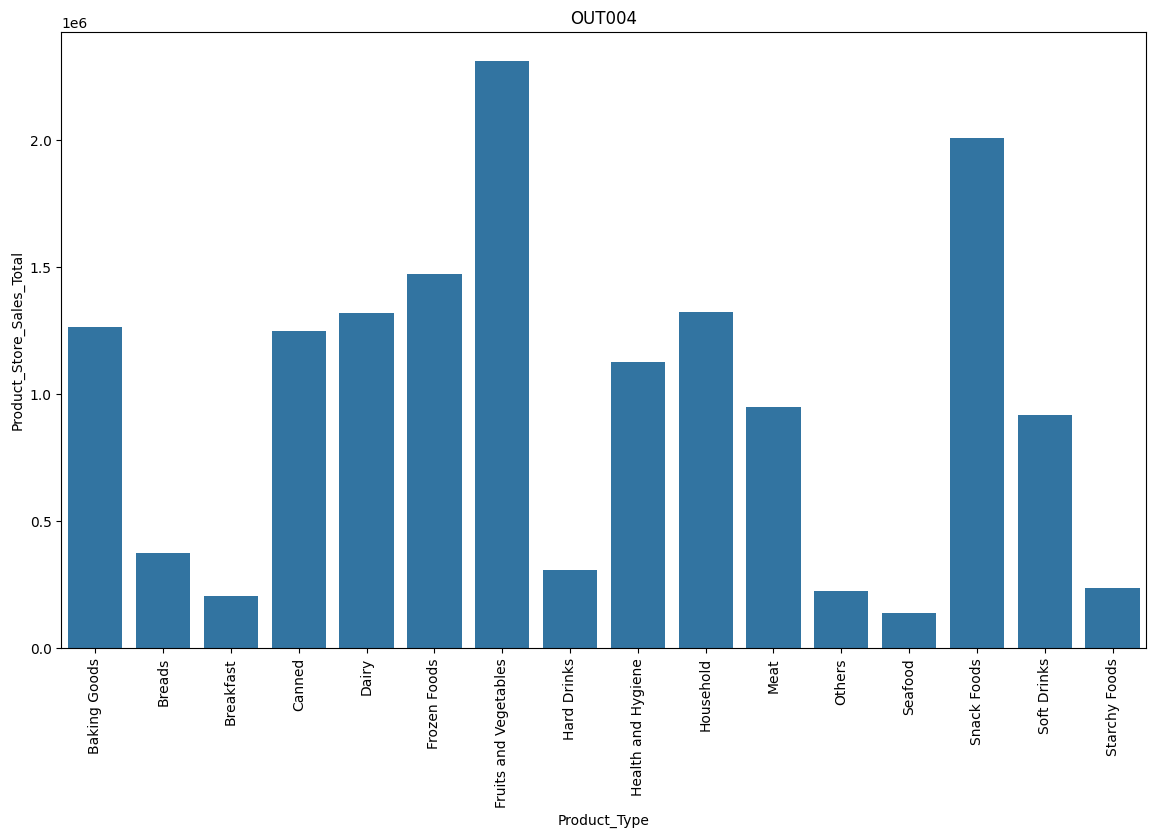

In [ ]:
# Barplot of sales per product type
data_OUT004 = (
    data.loc[data["Store_Id"] == "OUT004"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT004")
sns.barplot(x=data_OUT004.Product_Type, y=data_OUT004.Product_Store_Sales_Total)
plt.show()

**Observations:** OUT004 has generated the highest revenue from the sale of fruits and vegetables (~ 2500000) followed by snack foods (~ 2000000).

# **Data Preprocessing**

Final Data Checks


*   Class imbalance
*   Outliers
*   Missing data
*   Skewness
*   Drop Unnecessary Columns
*   Splitting data
*   Data Pre-processing Pipeline

**1. Check for Class Imbalance**

In [ ]:
# Loop through all selected categorical features
# and print the percentage distribution of each category
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(data[col].value_counts(normalize=True).round(3) * 100)


Column: Product_Sugar_Content
Product_Sugar_Content
Low Sugar    55.7
Regular      26.9
No Sugar     17.3
Name: proportion, dtype: float64

Column: Product_Type
Product_Type
Fruits and Vegetables    14.3
Snack Foods              13.1
Frozen Foods              9.3
Dairy                     9.1
Household                 8.4
Baking Goods              8.2
Canned                    7.7
Health and Hygiene        7.2
Meat                      7.1
Soft Drinks               5.9
Breads                    2.3
Hard Drinks               2.1
Others                    1.7
Starchy Foods             1.6
Breakfast                 1.2
Seafood                   0.9
Name: proportion, dtype: float64

Column: Store_Id
Store_Id
OUT004    53.4
OUT001    18.1
OUT003    15.4
OUT002    13.1
Name: proportion, dtype: float64

Column: Store_Size
Store_Size
Medium    68.8
High      18.1
Small     13.1
Name: proportion, dtype: float64

Column: Store_Location_City_Type
Store_Location_City_Type
Tier 2    71.5
Tier 1   

**Observations:** While some categorical features such as Product_Sugar_Content, Store_Size, and Store_Location_City_Type exhibit moderate class imbalance, none are extreme enough to warrant resampling or weighting adjustments in the modeling phase. This distribution is acceptable for model training without additional correction.

**2. Check for Outliers**

In [ ]:
# Detect outliers using the IQR method for all numeric features
for col in numeric_cols:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    # Identify data points that fall outside 1.5 * IQR
    outliers = data[(data[col] < q1 - 1.5 * iqr) | (data[col] > q3 + 1.5 * iqr)]

    # Print count of outliers
    print(f"{col}: {len(outliers)} outliers")

Product_Weight: 54 outliers
Product_Allocated_Area: 104 outliers
Product_MRP: 57 outliers
Store_Establishment_Year: 0 outliers
Product_Store_Sales_Total: 119 outliers


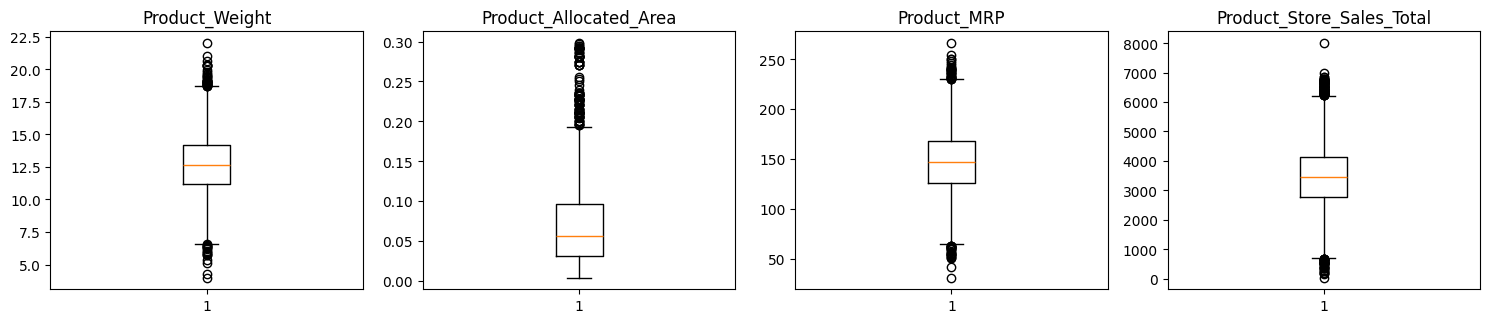

In [ ]:
# outlier detection using boxplot
plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_cols):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observations:** Outliers were detected in several numerical features using the IQR method. However, after examining their frequency and context during univariate analysis, they appear to reflect valid business scenarios (e.g., high Product_MRP or larger product weights). Therefore, I opted not to apply capping or transformation, as these values are likely informative for sales prediction rather than errors.

**3. Check for any missing data**

In [ ]:
# Re-check and display only columns with missing values (if any)
missing_data = data.isnull().sum()
missing_data = missing_data[missing_data > 0]
print(missing_data if not missing_data.empty else "No missing data found.")

No missing data found.


**4. Skewness Check for Target and Predictors**

In [ ]:
# Check skewness for numeric features and target
# Values > 1 or < -1 are considered highly skewed
data[numeric_cols + ["Product_Store_Sales_Total"]].skew().sort_values(ascending=False)

,0
Product_Allocated_Area,1.128093
Product_Store_Sales_Total,0.092024
Product_Store_Sales_Total,0.092024
Product_MRP,0.036513
Product_Weight,0.017514
Store_Establishment_Year,-0.758061


**Observations:** Product_Allocated_Area: Highly right-skewed (skew > 1) — could benefit from a log transformation to normalize.

Product_Store_Sales_Total (target): Nearly symmetric — no transformation required.

Product_MRP: Close to normal — transformation not needed.

Product_Weight: Symmetric — no transformation needed.

Store_Establishment_Year: Mild left skew — acceptable as-is, no transformation planned.

**Address the high number of Product Types (16) by grouping them.**
Creating two categories, perishables and non perishables, in order to reduce the number of product types to simplify one-hot encoding
This should simplify our model
Improve model generalization
Reduce the number of dummy variables
Reduces dimensionality

In [ ]:
# Grouping Product_Type into Perishables vs. Non Perishables
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"
# Create a new column 'Product_Type_Category' with grouped values
data['Product_Type_Category'] = data['Product_Type'].apply(change)

# Drop the original high-cardinality column
data.drop(columns=['Product_Type'], inplace=True)

data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,2009,Medium,Tier 2,Supermarket Type2,2842.40,Non Perishables
1,16.54,Low Sugar,0.144,171.43,1999,Medium,Tier 1,Departmental Store,4830.02,Perishables
2,14.28,Regular,0.031,162.08,1987,High,Tier 2,Supermarket Type1,4130.16,Non Perishables
3,12.10,Low Sugar,0.112,186.31,1987,High,Tier 2,Supermarket Type1,4132.18,Non Perishables
4,9.57,No Sugar,0.010,123.67,1998,Small,Tier 3,Food Mart,2279.36,Non Perishables


#**Drop Unnecessary Columns**


*   **Product_Id** has already been dropped.
*   **Product_Types** has been changed into Product_Type_Category.
*   **Store_Id** an unique identifiers and **Store_Establishment_Year** has already analyzed and found not predictive has to be dropped.

In [ ]:
# Drop unnecessary columns (exclude 'Product_Type' - already dropped earlier)
data = data.drop(
    ["Store_Id", "Store_Establishment_Year"],
    axis=1,
    errors='ignore'  # ignores columns that aren't found
)

# Print the number of rows and columns
print("Shape of the data:", data.shape)
print("-" * 100)  # Print a divider line

# Print the first 5 rows of the data
data.head()

Shape of the data: (8763, 9)
----------------------------------------------------------------------------------------------------


,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,Non Perishables


#**Separating Features and Target**

In [ ]:
# Separate features and target variable
X = data.drop("Product_Store_Sales_Total", axis=1)  # Feature set
y = data["Product_Store_Sales_Total"]               # Target variable

**Observations:** We separated the dataset into feature variables X and target variable y. The column Product_Store_Sales_Total is designated as the prediction target for our regression model. All other columns will be used as predictors.

**Split the data into training and testing sets to evaluate the model's performance on unseen data**

In [ ]:
# Splitting the data into train and test sets in 70:30 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True )

In [ ]:
# printing the shape of datasets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6134, 8), (2629, 8), (6134,), (2629,))

**Data Pre-processing Pipeline**

In [ ]:
# code to categorise the columns as we have dropped and changed some of the columns
numeric_cols=data.select_dtypes(include=np.number).columns.to_list()
category_cols=data.select_dtypes(include='object').columns.to_list()

# Create a preprocessing pipeline for the categorical features

preprocessor = make_column_transformer(
    (Pipeline([('encoder', OneHotEncoder(handle_unknown='ignore'))]), category_cols),
    remainder='passthrough'  # Leave all non-categorical columns (numerical) unchanged
)

**Observations:** We use make_column_transformer to apply a OneHotEncoder to the categorical columns while leaving numerical features untouched (remainder='passthrough'). The handle_unknown='ignore' ensures the model should not crash on unseen categories during prediction.

# **Model Building**

## Define functions for Model Evaluation

*   We will fit different models on the train data and observe their performance.
*   Try to improve that performance by tuning some hyperparameters available for that algorithm.
*   Use GridSearchCv for hyperparameter tuning and R-square score to optimize the model.

In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models weare choosing to be built are:
1. Random Forest
2. XGBoost

#**Model 1: Random Forest Model**

In [ ]:
# Define base Random Forest model
rf_model = RandomForestRegressor(random_state=42)

In [ ]:
# Create pipeline with preprocessing and Random Forest model
rf_pipeline = make_pipeline(preprocessor, rf_model)

In [ ]:
# Train the model pipeline on the training data
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

**Checking model performance on training set**

In [ ]:
# Evaluate performance on training data
rf_estimator_model_train_perf = model_performance_regression(rf_pipeline, X_train,y_train)
print("Training performance \n")
rf_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,107.528849,40.615143,0.989815,0.989802,0.015195


**Checking model performance on test set**

In [ ]:
# Evaluate performance on test data
rf_estimator_model_test_perf = model_performance_regression(rf_pipeline, X_test,y_test)
print("Testing performance \n")
rf_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,283.141589,107.84117,0.929404,0.929188,0.03915


**Observations:** The model may be only slightly overfitting, as it has a higher R-squared on the train set (0.989983) than on the test set (0.928597). This indicates that it performs slightly worse on unseen data but is still high > 90%.

#**Model 2: XGBoost**

In [ ]:
# Define base XGBoost model
xgb_model = XGBRegressor(random_state=42)

In [ ]:
# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_model)

In [ ]:
# Train the model pipeline on the training data
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=N...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

**Checking model performance on training set**

In [ ]:
# Evaluate performance on training data
xgb_estimator_model_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
print("Training performance \n")
xgb_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,126.521833,61.473187,0.985899,0.985881,0.021356


**Checking model performance on test set**

In [ ]:
# Evaluate performance on test data
xgb_estimator_model_test_perf = model_performance_regression(xgb_pipeline, X_test,y_test)
print("Testing performance \n")
xgb_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,302.671827,135.477845,0.919329,0.919082,0.047993


**Observations:** XGBoost has a R-squared of ~92%, seem to be performing about equal to Random Forest.

# **Model Performance Improvement - Hyperparameter Tuning**

#**Model 3: Random Forest-Hyperparameter Tuning**

In [ ]:
# Choose the type of classifier.
rf_tuned = RandomForestRegressor(random_state=42)

In [ ]:
# Create pipeline with preprocessing and RandomForestRegressor model
rf_tuned_pipeline = make_pipeline(preprocessor, rf_tuned)

# Grid of parameters to choose from
parameters = parameters = {
    'randomforestregressor__max_depth':[3, 4, 5, 6],
    'randomforestregressor__max_features': ['sqrt','log2',None],
    'randomforestregressor__n_estimators': [50, 75, 100, 125, 150]
}

In [ ]:
# Run the grid search
grid_obj = GridSearchCV(rf_tuned_pipeline, parameters, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

In [ ]:
# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=3, max_features='sqrt',
                                       n_estimators=50, random_state=42))])

**Checking model performance on training set**

In [ ]:
# Evaluate performance on training data
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
print("Training performance \n")
rf_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,508.023521,393.128387,0.772662,0.772365,0.144319


**Checking model performance on test set**

In [ ]:
# Evaluate performance on test data
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
print("Testing performance \n")
rf_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,502.550359,391.389618,0.7776,0.776921,0.141576


**Observations:** The performance metrics for the hypertuned Random Forest model are very low. Hypertuning did not improve model performance.

#**Model 4: XGBoost-Hyperparameter Tuning**

In [ ]:
# Choose the type of classifier
xgb_tuned = XGBRegressor(random_state=42)

In [ ]:
# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_tuned)

In [ ]:
#Grid of parameters to choose from
param_grid = {
    'xgbregressor__n_estimators': [50, 100, 150, 200],    # number of trees to build
    'xgbregressor__max_depth': [2, 3, 4],    # maximum depth of each tree
    'xgbregressor__colsample_bytree': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each tree
    'xgbregressor__colsample_bylevel': [0.4, 0.5, 0.6],    # percentage of attributes to be considered (randomly) for each level of a tree
    'xgbregressor__learning_rate': [0.01, 0.05, 0.1],    # learning rate
    'xgbregressor__reg_lambda': [0.4, 0.5, 0.6],    # L2 regularization factor
}

In [ ]:
# Run the grid search
grid_obj = GridSearchCV(xgb_pipeline, param_grid, scoring=r2_score, cv=3, n_jobs = -1)
grid_obj = grid_obj.fit(X_train, y_train)

In [ ]:
# Set the best estimator with the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

In [ ]:
# Fit the best algorithm to the training data
xgb_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category'])])),
                ('xgbregressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=N...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.01,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=2, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=50, n_jobs=None,
                              num_parallel_tree=None, ...))])

**Checking model performance on training set**

In [ ]:
# Evaluate performance on training data
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
print("Training performance \n")
xgb_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,853.001242,669.42738,0.35908,0.358243,0.270741


**Checking model performance on test set**

In [ ]:
# Evaluate performance on test data
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
print("Testing performance \n")
xgb_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,848.056282,667.878973,0.366677,0.364743,0.26735


**Observations:** Tuned models (RF & XGBoost) have underperformed.

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
    xgb_estimator_model_train_perf.T,xgb_tuned_model_train_perf.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Random Forest",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,107.528849,508.023521,126.521833,853.001242
MAE,40.615143,393.128387,61.473187,669.427380
R-squared,0.989815,0.772662,0.985899,0.359080
Adj. R-squared,0.989802,0.772365,0.985881,0.358243
MAPE,0.015195,0.144319,0.021356,0.270741


In [ ]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
    xgb_estimator_model_test_perf.T,xgb_tuned_model_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Random Forest",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Random Forest,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,283.141589,502.550359,302.671827,848.056282
MAE,107.841170,391.389618,135.477845,667.878973
R-squared,0.929404,0.777600,0.919329,0.366677
Adj. R-squared,0.929188,0.776921,0.919082,0.364743
MAPE,0.039150,0.141576,0.047993,0.267350


**Observations:**


*   **Random Forest model** consistently outperformed all others across every metric, including lowest RMSE, MAE, and MAPE, and highest R-squared on both train and test sets.
*   Based on the above I am moving forward with the Base Random Forest Model even though XGBoost Tuned has the low gap between the R-squared of train vs. test data.

**Model Serialization & Sanity Check**

Based on the model comparison, the Random Forest model demonstrated the best performance on the testing data. Therefore, we will serialize **Random Forest** model for deployment.

In [ ]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [ ]:
# Define model filename and save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "backend_files/superkart_model.joblib"

In [ ]:
# Save the trained model pipeline
joblib.dump(rf_pipeline, saved_model_path,compress=9)
print(f"Model saved successfully at: {saved_model_path}")

Model saved successfully at: backend_files/superkart_model.joblib


In [ ]:
# ReLoad the saved model pipeline from the file to test deserialization
loaded_model = joblib.load(saved_model_path)
print(" Model loaded successfully.")

 Model loaded successfully.


In [ ]:
loaded_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('pipeline',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
# ensure that the saved model is loaded before making predictions, Run a prediction test
sample_preds = loaded_model.predict(X_test)
print("Sample predictions from reloaded model:", sample_preds[:5])

Sample predictions from reloaded model: [3394.4229 3373.2931 2406.7253 1891.1424 4698.6246]


# **Deployment - Backend**

## Points to note before executing the below cells
- Create a GitHub account if you don't already have one at [github.com](https://github.com)
- Generate a **Personal Access Token**
  - Make sure the token has **repo** scope (full control of private repositories)
- The serialized ML model file (`superkart_model.joblib`) should already be present in the `backend_files` folder before pushing to GitHub
- We will deploy **both the Flask backend and the Streamlit frontend as separate Docker containers** inside a GitHub Codespace, and connect them using a **Docker network**

## Flask Web Framework

Flask is a lightweight, flexible Python web framework used to build web applications and APIs quickly and easily.

Flask allows you to:
- Create web routes (URLs that users can access)
- Handle HTTP requests and responses
- Build REST APIs to expose machine learning models or other services

**Note:** Once the backend_files folder is created, upload the model file (superkart_model.joblib) to it.

In [ ]:
# Create a folder for storing the files needed for backend server deployment
import os
os.makedirs("backend_files", exist_ok=True)

In [ ]:
%%writefile backend_files/app.py

# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize Flask app with a name
superkart_api = Flask("SuperKart")

# Load the trained model
model = joblib.load("superkart_model.joblib")

# Define a route for the home page
@superkart_api.get('/')
def home():
    return "Welcome to the SuperKart System"

# Define an endpoint to predict sales for a single product
@superkart_api.post('/v1/predict')
def predict_sales():
    # Get JSON data from the request
    data = request.get_json()

    # Extract relevant features from the input data
    sample = {
    'Product_Weight': data['Product_Weight'],
    'Product_Sugar_Content': data['Product_Sugar_Content'],
    'Product_Allocated_Area': data['Product_Allocated_Area'],
    'Product_MRP': data['Product_MRP'],
    'Store_Size': data['Store_Size'],
    'Store_Location_City_Type': data['Store_Location_City_Type'],
    'Store_Type': data['Store_Type'],
    'Product_Type_Category': data['Product_Type_Category']
}

    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a prediction using the trained model
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Sales': prediction})

# Define an endpoint to predict sales for a batch of products
@superkart_api.post('/v1/predictbatch')
def predict_sales_batch():
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the file into a DataFrame
    input_data = pd.read_csv(file)

    # Make predictions for the batch data
    predictions = model.predict(input_data).tolist()

    # Create an output dictionary mapping row index to predicted sales
    output_dict = {str(i): round(pred, 2) for i, pred in enumerate(predictions)}

    return output_dict


# Run the Flask app in debug mode
if __name__ == '__main__':
    superkart_api.run(debug=True)

Writing backend_files/app.py


In the given code snippet, the decorators @superkart_api.get('/'), @superkart_api.post('/v1/predict'), and @superkart_api.post('/v1/predictbatch') are used in Flask, a web framework for building APIs in Python.

**What is a Decorator?**
In Python, a decorator is a function that modifies or extends the behavior of another function. In Flask, decorators are used to map URL routes to Python functions.

**Summary of flow of script**
1.   **Model Loading (joblib.load)** – Loads a pre-trained ML model (superkart_model.joblib) trained to predict product sales based on product and store features.
2.   **Flask App Setup** – Initializes a simple Flask web server.
3.   **Routes:**

    * GET / – Home route, returns a welcome message.
    * POST /v1/predict – Accepts a single product's data as JSON, returns a sales prediction.
    * POST /v1/predictbatch – Accepts a CSV file of multiple products, returns predictions for all rows.
4.   **Running** – In production, the app is served using Gunicorn (as defined in the Dockerfile).

## Dependencies File

In [ ]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]

Writing backend_files/requirements.txt


## Dockerfile

In [ ]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:superkart_api`: Runs the Flask app (assuming `app.py` contains the Flask instance named `superkart_api`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Writing backend_files/Dockerfile


This Dockerfile is used to **containerize the Flask application**, making it easy to deploy and run consistently across different environments.

**Line-by-Line Explanation**

**FROM python:3.9-slim** – Uses a lightweight Python 3.9 base image.

**WORKDIR /app** – Sets /app as the working directory inside the container.

**COPY . .** – Copies all files from the local directory into the container.

**RUN pip install ...** – Installs all required packages from requirements.txt.

**CMD [...]** – Starts the Flask app with Gunicorn, binding it to port 7860.

# **Deployment - Frontend**



*   The frontend Streamlit app will communicate with the backend **Flask API over a Docker network**
*   Instead of calling a public URL, the Streamlit app will call http://backend:7860 - here backend is the container name we will assign when running the Docker container, and Docker's internal DNS resolves it automatically (For example, docker run -d --name backend --network superkart-app-network -p 7860:7860 superkart-backend)
*  Both containers will be launched inside the same GitHub Codespace.

## Streamlit for Interactive UI

In [ ]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [ ]:
%%writefile frontend_files/app.py

import streamlit as st
import pandas as pd
import requests

# Base URL of the Flask backend
BACKEND_URL ="http://host.docker.internal:7860"

# Page title
st.title("SuperKart System")
st.write(
    "Enter the product and store details below to predict the total sales."
)

# Input fields for product and store data
Product_Weight = st.number_input("Product Weight", min_value=0.0, value=12.66)
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
Product_Allocated_Area = st.number_input("Product Allocated Area", min_value=0.0, value=0.027)
Product_MRP = st.number_input("Product MRP", min_value=0.0, value=117.08)
Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])
Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
Store_Type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Supermarket Type3", "Departmental Store", "Food Mart"])
Product_Type_Category = st.selectbox("Product Type Category", ["Perishables", "Non Perishables"])

# Create JSON payload
product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Product_Type_Category": Product_Type_Category
}

# Single Prediction
if st.button("Predict", type='primary'):

    response = requests.post(
        f"{BACKEND_URL}/v1/predict",
        json=product_data
    )

    if response.status_code == 200:
        result = response.json()
        predicted_sales = result["Sales"]
        st.success(f"Predicted Product Store Sales Total: ₹{predicted_sales:.2f}")
    else:
        st.error("Unable to connect to the prediction API.")

# Batch Prediction
st.subheader("Batch Prediction")

uploaded_file = st.file_uploader(
    "Upload a CSV file",
    type=["csv"]
)

if uploaded_file is not None:

    if st.button("Predict for Batch", type='primary'):

        response = requests.post(
            f"{BACKEND_URL}/v1/predictbatch",
            files={"file": uploaded_file}
        )

        if response.status_code == 200:
            results = response.json()

            st.success("Predictions completed successfully!")

            try:
                if isinstance(results, list):
                    df = pd.DataFrame(results)
                elif isinstance(results, dict):
                    # Check if all values are scalars
                    if all(not isinstance(v, (list, dict)) for v in results.values()):
                        df = pd.DataFrame([results])
                    else:
                        df = pd.DataFrame(results)
                else:
                    df = pd.DataFrame({"Result": [results]})

                st.dataframe(df, use_container_width=True)

            except Exception as e:
                st.error(f"Unable to display results as a table: {e}")
                st.json(results)

        else:
            st.error("Unable to connect to the prediction API.")


Writing frontend_files/app.py


## Dependencies File

In [ ]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Writing frontend_files/requirements.txt


## Dockerfile

In [ ]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing frontend_files/Dockerfile


# **Pushing Deployment Files to GitHub**

The code below authenticates with your GitHub account using the Personal Access Token, creates a new public repository, and pushes all the backend and frontend files to it.

The files are pushed with a folder structure that keeps backend and frontend separate:

repo root/

    backend/
        app.py
        requirements.txt
        Dockerfile
        superkart_model.joblib
    frontend/
        app.py
        requirements.txt
        Dockerfile

This folder structure is important because when we open a Codespace from this repo, we will cd into each folder separately to build its Docker image.

**Points to note before executing the below cell**


*   Create a GitHub account and generate a Personal Access Token.
*   Once you have the token, store it as a Colab Secret.

In [ ]:
# Your GitHub Personal Access Token

from google.colab import userdata
GITHUB_TOKEN = userdata.get('SuperKartAccess')  # Code with the secret name for your token

# After executing this code, you may be prompted to grant access. Click "Grant Access" to continue.

In [ ]:
#library for GitHub
!pip install PyGithub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.6/455.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.5 MB/s eta 0:00:00


In [ ]:
import shutil
from github import Github, UnknownObjectException

# Name for the new repository
REPO_NAME = "SuperKart_ModelDeployment"

# Authenticate with GitHub
g = Github(GITHUB_TOKEN)
user = g.get_user()
print(f"Authenticated as: {user.login}")

# Try to get the repository; if it doesn't exist, create it
try:
    repo = user.get_repo(REPO_NAME)
    print(f"Repository '{REPO_NAME}' already exists. Using existing repository.")
except UnknownObjectException:
    # If the repository does not exist, create it
    repo = user.create_repo(
        REPO_NAME,
        description="It is a data analysis and machine learning project written in Python. Analysing sales data to uncoverbusiness insights.",
        private=False,
        auto_init=True  # Creates an initial README so the repo is not empty
    )
    print(f"Repository created successfully: {repo.html_url}")

# Dictionary mapping repo file paths to local file paths
# Backend files go under backend/ and frontend files go under frontend/
files_to_push = {
    "backend/app.py": "backend_files/app.py",
    "backend/requirements.txt": "backend_files/requirements.txt",
    "backend/Dockerfile": "backend_files/Dockerfile",
    "backend/superkart_model.joblib": "backend_files/superkart_model.joblib",
    "frontend/app.py": "frontend_files/app.py",
    "frontend/requirements.txt": "frontend_files/requirements.txt",
    "frontend/Dockerfile": "frontend_files/Dockerfile",
}

for repo_path, local_path in files_to_push.items():
    # Read the file content as bytes
    with open(local_path, "rb") as f:
        content = f.read()

    # Check if the file already exists in the repository
    try:
        # Get the existing file to retrieve its SHA
        file_in_repo = repo.get_contents(repo_path, ref="main")
        # If the file exists, update it
        repo.update_file(
            path=repo_path,
            message=f"Update {repo_path}",
            content=content,
            sha=file_in_repo.sha,
            branch="main"
        )
        print(f"Updated: {repo_path}")
    except UnknownObjectException:
        # If the file does not exist, create it
        repo.create_file(
            path=repo_path,
            message=f"Add {repo_path}",
            content=content,
            branch="main"
        )
        print(f"Uploaded: {repo_path}")

print(f"\nAll files pushed successfully to: {repo.html_url}")

Authenticated as: bablygithub
Repository created successfully: https://github.com/bablygithub/SuperKart_ModelDeployment
Uploaded: backend/app.py
Uploaded: backend/requirements.txt
Uploaded: backend/Dockerfile
Uploaded: backend/superkart_model.joblib
Uploaded: frontend/app.py
Uploaded: frontend/requirements.txt
Uploaded: frontend/Dockerfile

All files pushed successfully to: https://github.com/bablygithub/SuperKart_ModelDeployment


**After the files have been pushed successfully, deploy the app using GitHub Codespaces.**

# **Inferencing using Flask API**

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the deployed Flask API running inside a GitHub Codespace to perform **online** and **batch inference** from this Colab notebook.

We will:
1. Send API requests for both online and batch inference.
2. Process and check the model predictions.

**Before running the cells below**, make sure:
- Your Codespace is running with both containers up
- Port 7860 has been set to **Public** in the Codespace Ports tab
- You have copied the forwarded URL for port 7860
- You have also referred the document titled **`Guided Hands-on - Containerized Model Deployment using GitHub Codespaces`** provided

In [ ]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [ ]:
model_root_url = "https://organic-bassoon-7ww67gg4jwp3wxg6-7860.app.github.dev"  # Code with  Codespace forwarded URL for port 7860

Replace the URL above with the actual forwarded URL from your Codespace's Ports tab. It will look something like `https://organic-space-abcd1234-7860.app.github.dev`. Make sure there is no trailing slash at the end.

This URL is a tunnel that Codespaces creates to route external HTTP requests into your Codespace and to the Flask container running on port 7860.

In [ ]:
model_root_url

'https://organic-bassoon-7ww67gg4jwp3wxg6-7860.app.github.dev'

In [ ]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

In [ ]:
model_url

'https://organic-bassoon-7ww67gg4jwp3wxg6-7860.app.github.dev/v1/predict'

Since our model predictions are provided by the following endpoint we created using Flask, we need to invoke the same to make prediction.

> ```@superkart_api.post('/v1/predict')```

In [ ]:
model_batch_url = model_root_url + "/v1/predictbatch"  # Endpoint for batch inference

> ```@superkart_api.post('/v1/predictbatch')```

## Online

**Online Inference:** Sending a single request to the API and receiving an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.  
* This data is sent as a JSON payload in a POST request to the model endpoint.

* The model processes the input features and returns a prediction.

In [ ]:
payload = {
  "Product_Weight": 12.66,
  "Product_Sugar_Content": "Low Sugar",
  "Product_Allocated_Area": 0.027,
  "Product_MRP": 117.08,
  "Store_Size": "Medium",
  "Store_Location_City_Type": "Tier 2",
  "Store_Type": "Supermarket Type2",
  "Product_Type_Category": "Non Perishables"
}

In [ ]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [ ]:
response

<Response [200]>

`<Response [200]>` indicates that the HTTP request was successful.  

- `Response` is the object returned by `requests.post()`.  
- `[200]` is the HTTP status code, meaning **OK** (the request was processed successfully).  

In [ ]:
print(response.json())

{'Sales': 3122.2413000000006}


`response.json()` is used to parse the response body as JSON.  
- If the API returns data in JSON format, `.json()` converts it into a Python dictionary.  
- This allows easy access to specific values using keys.  

## Batch

**Batch Inference:** Sending multiple inputs in a single request, allowing efficient processing of large datasets. This is ideal for analyzing historical data at scale.
*   This data is sent as a CSV file in a POST request to the model endpoint.
*   The model processes each row containing the input features and returns the predictions for each row as one single JSON payload.

In [ ]:
batch_dataset = pd.read_csv("/content/drive/MyDrive/Python/SuperKart/Batch_Data_SuperKart.csv")

**Note**: The batch CSV file must contain all the feature columns expected by the model: `Product_Weight`, `Product_Sugar_Content`, `Product_Allocated_Area`, `Product_MRP`, `Store_Size`, `Store_Location_City_Type`, `Store_Type`, `Product_Id_char`, `Store_Age_Years`, `Product_Type_Category`.

In [ ]:
# Prepare batch input for API request
batch_input = {
    'file': batch_dataset.to_csv(header=True, index=False).encode('utf-8')
}

This code prepares the product data as a **file-like object** to send in an API request (in the `files` parameter of `requests.post`).

- `batch_dataset`: This is a Pandas DataFrame containing the product data loaded from a CSV file.

- `.to_csv(header=True, index=False)`: Converts the DataFrame into a CSV **string**, keeping the column headers (`header=True`) but **excluding the index** (`index=False`).

- `.encode('utf-8')`: Encodes the CSV string into **bytes** (UTF-8 format), which is necessary for sending it over an HTTP request.

- `'file': ...`: Wraps the encoded CSV data in a dictionary with the key `'file'`, which is expected by the Flask backend.

In [ ]:
# Send request to the model API for batch predictions
response = requests.post(
    model_batch_url,  # Model endpoint URL
    files=batch_input
)

This line sends a **POST request** to the deployed model API to perform **batch sales prediction**.

- `requests.post(...)`: This uses the `requests` library to make a **POST** request to a web server (in this case, our API endpoint for batch predictions).

- `model_batch_url`: This is the URL endpoint where the batch prediction API is hosted. It should look like this:\
  `"https://<your-codespace-name>-7860.app.github.dev/v1/predictbatch"`

- `files=batch_input`: This sends the batch data file (e.g., a CSV) as part of the request using the `files` parameter.

- `response`: This is the result of the API call and contains the response from the server, including predicted sales values.

In [ ]:
response

<Response [200]>

In [ ]:
# Extract predictions from API response
response.text

'{"0":4284.18,"1":2817.71,"2":3961.67,"3":1864.11,"4":4121.35,"5":5187.97,"6":2107.42,"7":2359.15,"8":5305.68,"9":2510.08}\n'

As we can see, we receive a JSON where each key represents a row index, and the value represents the model's predicted sales for that product.